In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('cybersecurity_attacks.csv')

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# Extract year-month format for grouping
df['daily'] = df['Timestamp'].dt.date

# Get the unique attack types
attack_types = df['Attack Type'].unique()
year_months = df['daily'].unique()
# Create empty matrices for occurrence and anomaly score
occurrence_matrix = pd.DataFrame(0, index=year_months, columns=attack_types)
anomaly_score_matrix = pd.DataFrame(0.0, index=year_months, columns=attack_types)

In [ ]:
for attack in attack_types:
    for period in year_months:
        subset = df[(df['Attack Type'] == attack) & (df['daily'] == period)]

        # Count occurrences
        occurrence_matrix.loc[period, attack] = len(subset)

        # Compute average anomaly score
        if not subset.empty:
            anomaly_score_matrix.loc[period, attack] = subset['Anomaly Scores'].mean()

In [ ]:
occurrence_matrix.to_csv('daily_topic_occurrence_matrix.csv')
anomaly_score_matrix.to_csv('daily_anomaly_score_matrix.csv')

print("Daily matrices created and saved successfully.")

Daily matrices created and saved successfully.


Epoch 1/150


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - loss: 0.2681 - val_loss: 0.1316 - learning_rate: 0.0010
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.1394 - val_loss: 0.1279 - learning_rate: 0.0010
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.1377 - val_loss: 0.1238 - learning_rate: 0.0010
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - loss: 0.1357 - val_loss: 0.1208 - learning_rate: 0.0010
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.1307 - val_loss: 0.1234 - learning_rate: 0.0010
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 0.1295 - val_loss: 0.1171 - learning_rate: 0.0010
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.1284 - val_loss: 0.1152 - learning_rate: 0.0010
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - loss: 0.1254 - val_loss: 0.1130 - learning_rate: 0.0010
Epoch 9/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.1216 - val_loss: 0.1094 - learning_rate: 0.0010
Epoch 10/150
35/35 

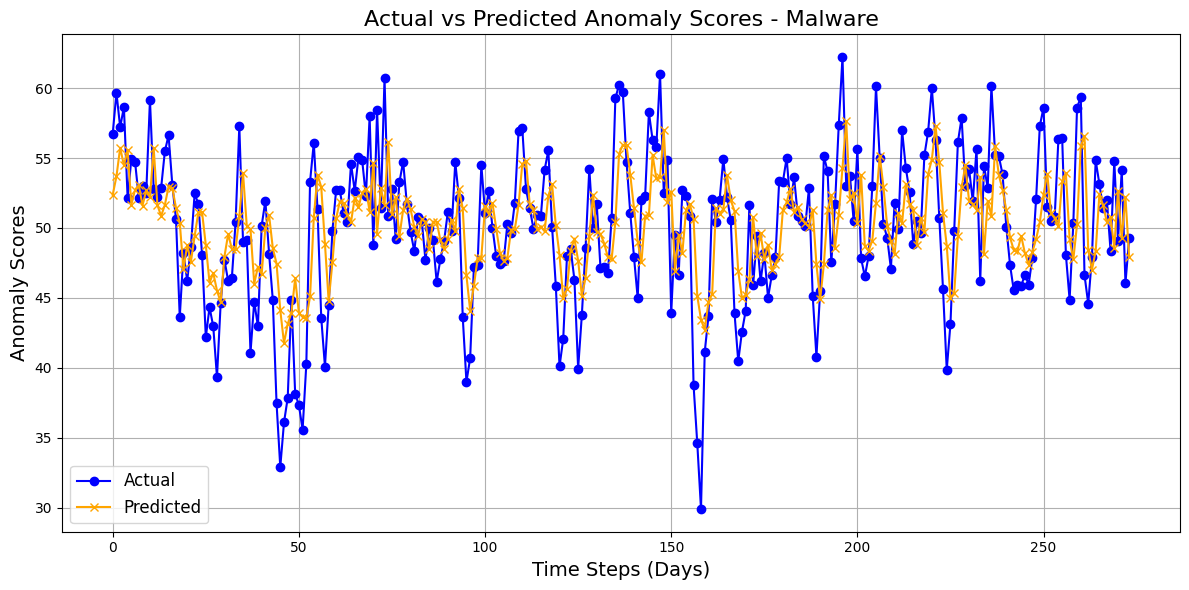

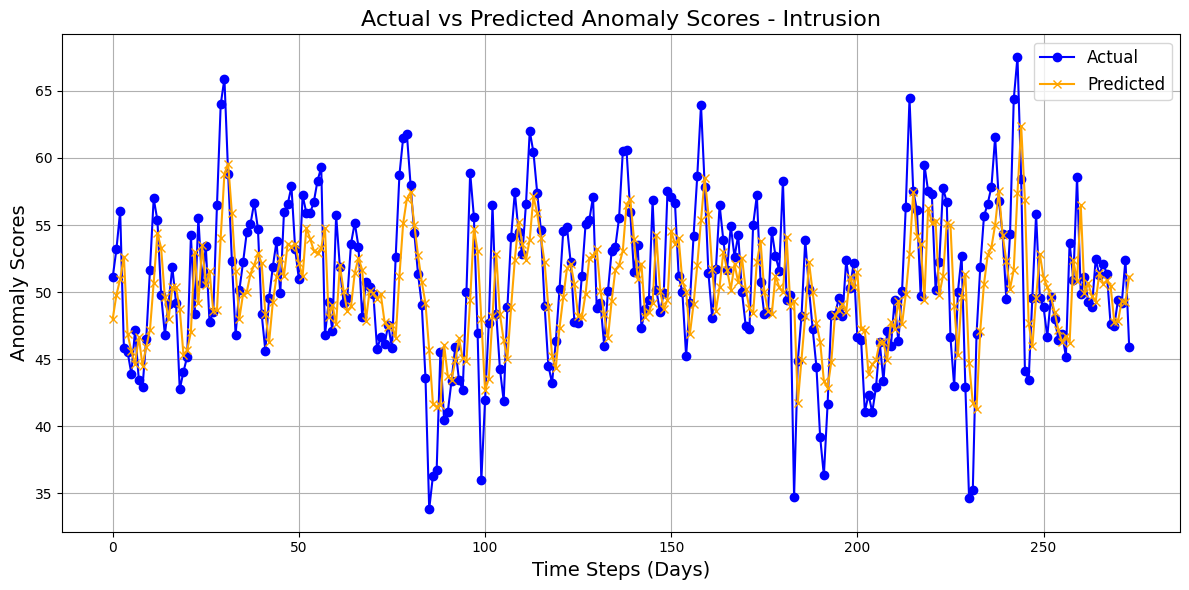

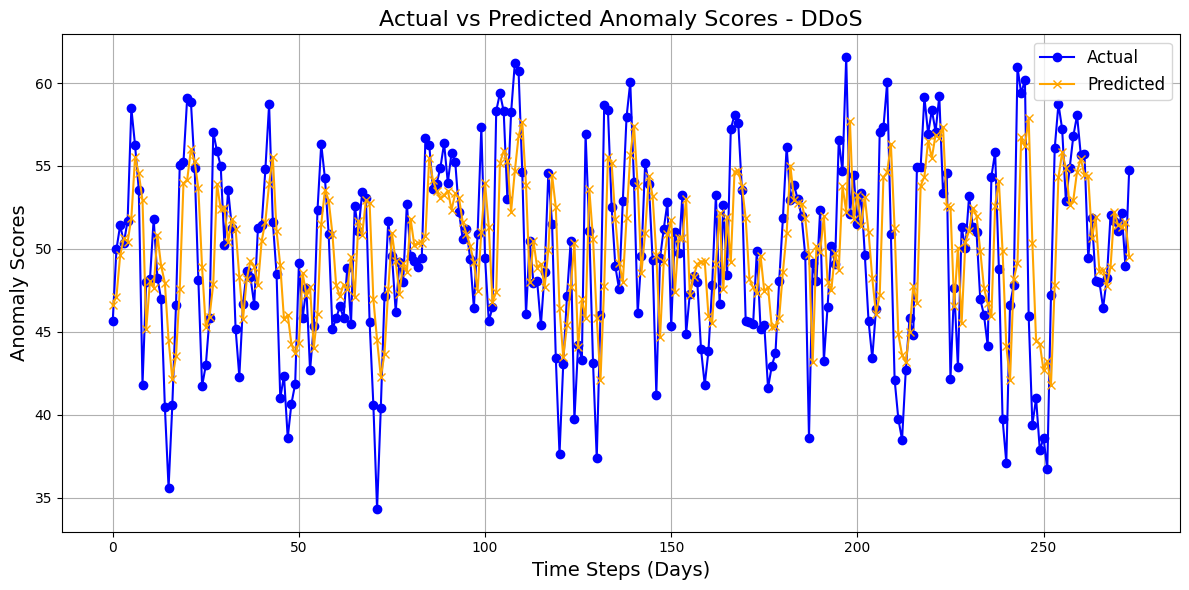

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

Future Prediction for Anomaly Scores for the next day:
          Malware  Intrusion  DDoS
Next Day     49.0       47.0  54.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Load the cybersecurity attacks dataset
df = pd.read_csv('cybersecurity_attacks.csv')

# Preprocess the data: Convert 'Timestamp' to datetime and group by day for anomaly scores of each attack type
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Create a DataFrame with average anomaly scores per day for each attack type
df_daily = df.groupby([df['Timestamp'].dt.date, 'Attack Type'])['Anomaly Scores'].mean().unstack(fill_value=0)

# Filter only relevant attack types: 'Malware', 'Intrusion', 'DDoS'
relevant_attacks = ['Malware', 'Intrusion', 'DDoS']
df_filtered = df_daily[relevant_attacks]

# Apply a rolling mean to smooth daily data and reduce noise
df_smoothed = df_filtered.rolling(window=3, min_periods=1).mean()

# Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_smoothed)

# Function to prepare data for LSTM (n_steps = window size for past days)
def prepare_data(data, n_steps=12):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i-n_steps:i])
        y.append(data[i])
    return np.array(X), np.array(y)

# Use the past 12 days to predict the next day's anomaly scores for all attack types
n_steps = 12
X, y = prepare_data(data_scaled, n_steps=n_steps)

# Split the data into training and testing sets (80% train, 20% test)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the LSTM model with optimized architecture and regularization
model = Sequential([
    Bidirectional(LSTM(128, activation='relu', return_sequences=True, input_shape=(n_steps, X.shape[2]))),
    Dropout(0.4),
    Bidirectional(LSTM(64, activation='relu')),
    Dropout(0.4),
    Dense(X.shape[2])  # Output layer with three features (anomaly scores for DDoS, Malware, Intrusion)
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the LSTM model with increased epochs for better convergence
history = model.fit(X_train, y_train, epochs=150, batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping, lr_scheduler], verbose=1)

# Predict on the test set
y_pred = model.predict(X_test)

# Inverse transform the predictions and actual values
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled_lstm = scaler.inverse_transform(y_test)

# Calculate Mean Absolute Error (MAE) for each attack type
mae_per_attack_type = {}
for i, attack in enumerate(relevant_attacks):
    mae_per_attack_type[attack] = mean_absolute_error(y_test_rescaled[:, i], y_pred_rescaled[:, i])

print("Mean Absolute Error (MAE) per Attack Type:")
for attack_type, mae in mae_per_attack_type.items():
    print(f"{attack_type}: {mae:.4f}")

# Plot actual vs predicted for each attack type with improved visualization settings
for i, attack in enumerate(relevant_attacks):
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_rescaled[:, i], label='Actual', marker='o', color='blue')
    plt.plot(y_pred_rescaled[:, i], label='Predicted', marker='x', color='orange')
    plt.title(f'Actual vs Predicted Anomaly Scores - {attack}', fontsize=16)
    plt.xlabel('Time Steps (Days)', fontsize=14)
    plt.ylabel('Anomaly Scores', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Predict future values for each attack type for the next day based on last n_steps of data
last_n_steps = data_scaled[-n_steps:]  # Take the last 12 days as input
future_pred_scaled = model.predict(last_n_steps[np.newaxis, :, :])

# Inverse transform the future prediction
future_pred_rescaled = scaler.inverse_transform(future_pred_scaled)[0]

# Clip negative values to zero if necessary (if scores are expected to be non-negative)
future_pred_rescaled = np.clip(future_pred_rescaled, 0, None).round()

# Display future predictions for all attack types with improved formatting
future_df = pd.DataFrame([future_pred_rescaled], columns=relevant_attacks, index=['Next Day'])
print("\nFuture Prediction for Anomaly Scores for the next day:")
print(future_df)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

Mean Absolute Error (MAE) per Attack Type - ARIMA:
Malware: 10.9200
DDoS: 8.2864
Intrusion: 7.9777


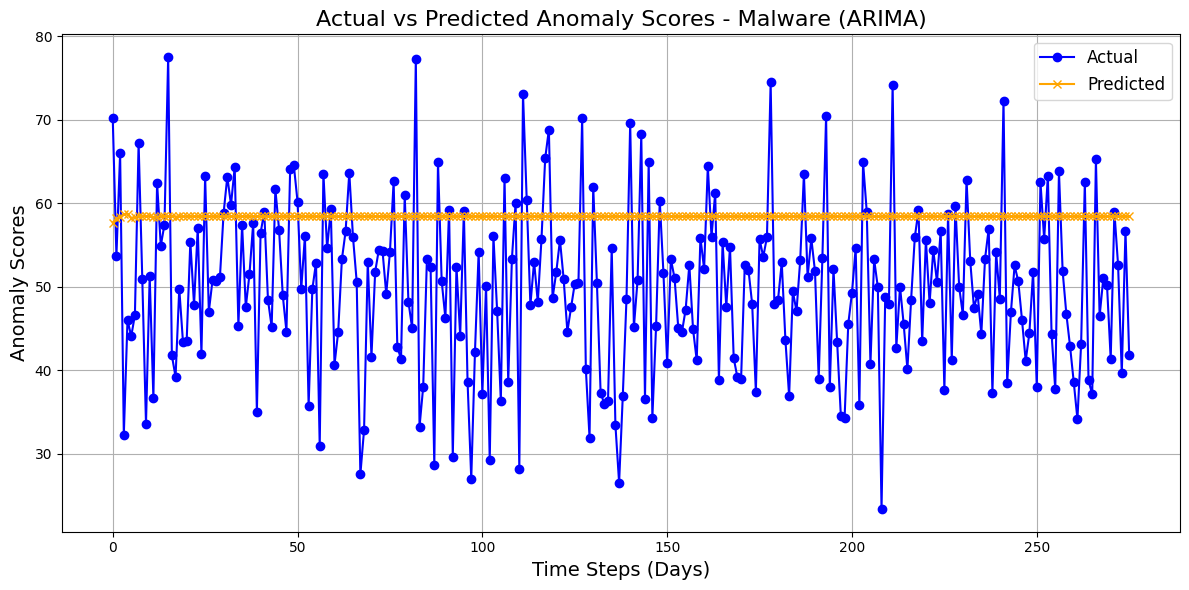

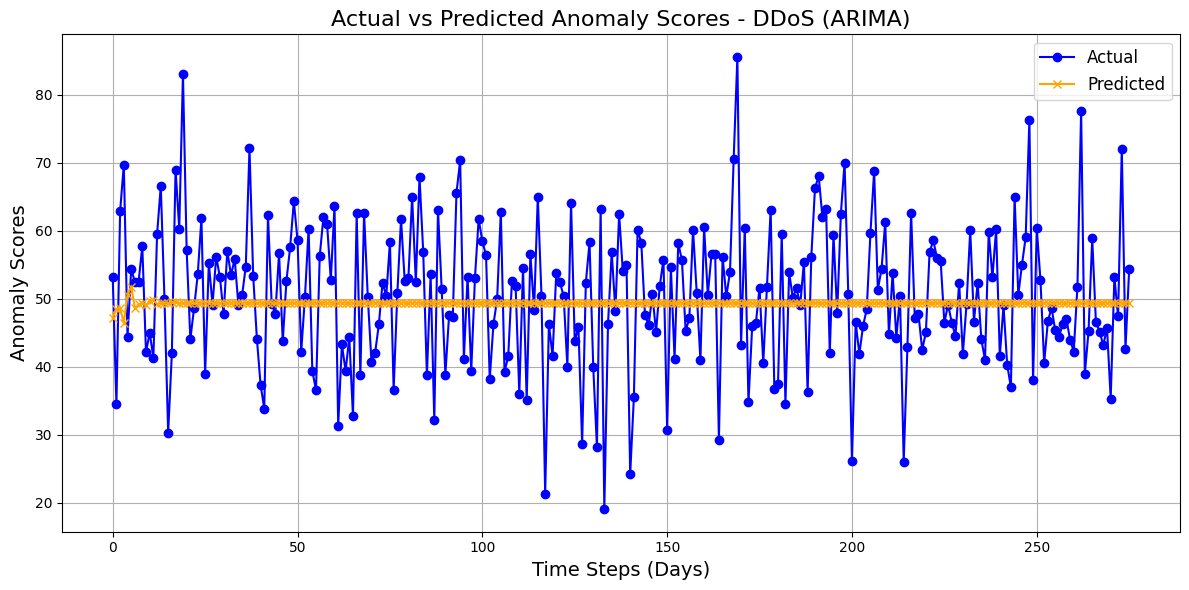

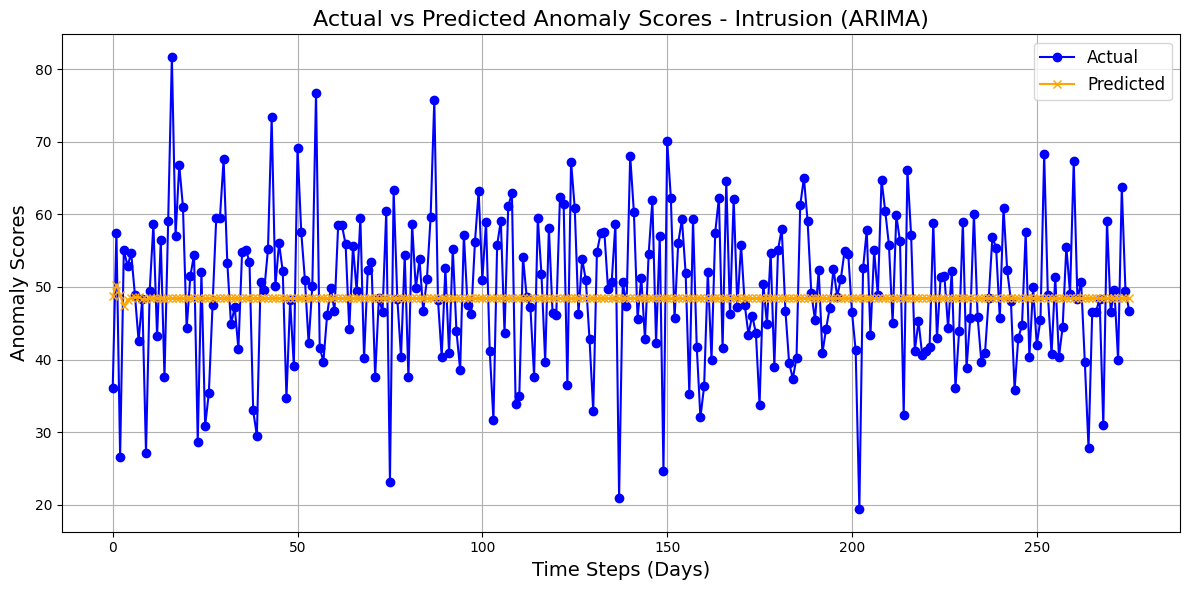

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm


Future Prediction for Anomaly Scores for the next day (ARIMA):
            Malware       DDoS  Intrusion
Next Day  48.382485  50.256923  50.126524


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# Load the cybersecurity anomaly score dataset
occurrence_matrix = pd.read_csv('daily_anomaly_score_matrix.csv', index_col=0)

# List of relevant attack types (columns in the dataset)
relevant_attacks = occurrence_matrix.columns  # Get column names

# Fill any missing values (if present) with zeros
occurrence_matrix = occurrence_matrix.fillna(0)

# Split data into training (80%) and testing (20%) sets
train_size = int(0.8 * len(occurrence_matrix))
train_data = occurrence_matrix[:train_size]
test_data = occurrence_matrix[train_size:]

# Initialize variables for storing predictions and errors
mae_per_attack_type_arima = {}
y_pred_arima_rescaled = []

# Loop through each attack type (column) and fit an ARIMA model
for attack in relevant_attacks:
    # Use the attack type's series from train and test data
    train_series = train_data[attack]
    test_series = test_data[attack]

    # Fit an ARIMA model with fixed order (p, d, q) = (5, 1, 0)
    model = ARIMA(train_series, order=(5, 1, 0))
    model_fit = model.fit()

    # Forecast the next values for the length of the test set
    y_pred_arima = model_fit.forecast(steps=len(test_series))
    y_pred_arima_rescaled.append(y_pred_arima)

    # Calculate Mean Absolute Error (MAE) for the current attack type
    mae = mean_absolute_error(test_series, y_pred_arima)
    mae_per_attack_type_arima[attack] = mae

# Convert predictions into a numpy array for plotting
y_pred_arima_rescaled = np.column_stack(y_pred_arima_rescaled)

# Print Mean Absolute Error for each attack type
print("Mean Absolute Error (MAE) per Attack Type - ARIMA:")
for attack_type, mae in mae_per_attack_type_arima.items():
    print(f"{attack_type}: {mae:.4f}")

# Plot actual vs predicted values for each attack type
for i, attack in enumerate(relevant_attacks):
    plt.figure(figsize=(12, 6))
    plt.plot(test_data[attack].values, label='Actual', marker='o', color='blue')
    plt.plot(y_pred_arima_rescaled[:, i], label='Predicted', marker='x', color='orange')
    plt.title(f'Actual vs Predicted Anomaly Scores - {attack} (ARIMA)', fontsize=16)
    plt.xlabel('Time Steps (Days)', fontsize=14)
    plt.ylabel('Anomaly Scores', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Predict future values for all attack types for the next day based on the last n_steps of data
future_pred_arima_rescaled = []
for attack in relevant_attacks:
    # Fit ARIMA on the entire series to forecast the next day
    model = ARIMA(occurrence_matrix[attack], order=(5, 1, 0))
    model_fit = model.fit()
    future_pred_arima = model_fit.forecast(steps=1)
    future_pred_arima_rescaled.append(future_pred_arima.iloc[0])

# Convert future predictions into a DataFrame and display them
future_df_arima = pd.DataFrame([future_pred_arima_rescaled], columns=relevant_attacks, index=['Next Day'])
print("\nFuture Prediction for Anomaly Scores for the next day (ARIMA):")
print(future_df_arima)


Mean Absolute Error (MAE) per Attack Type - Random Forest:
Malware: 9.8228
DDoS: 9.5881
Intrusion: 10.0581


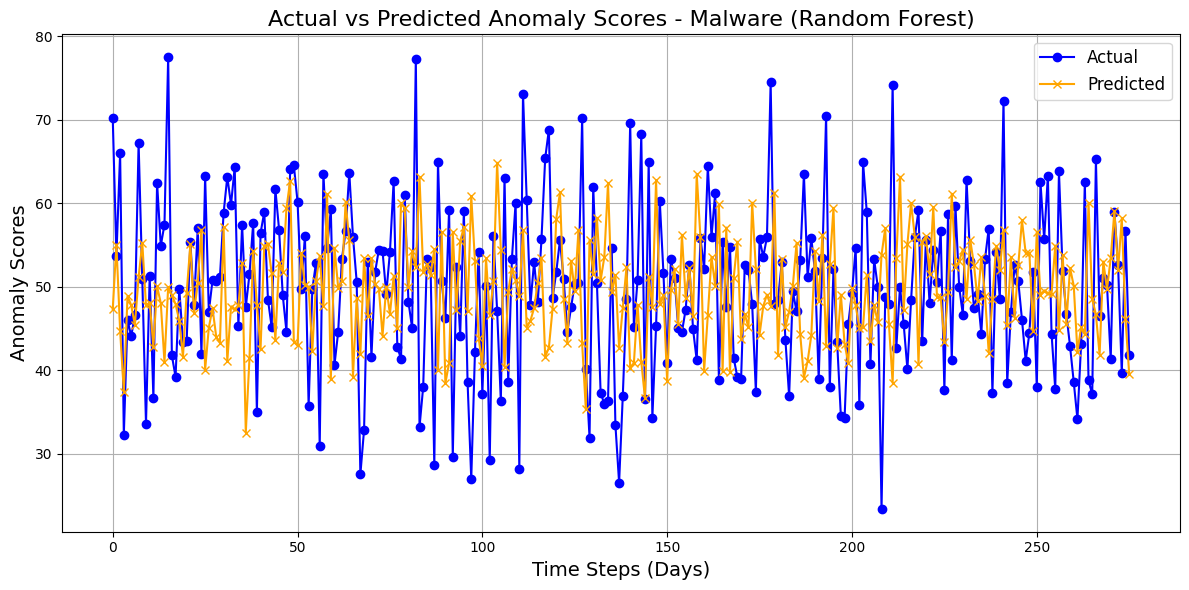

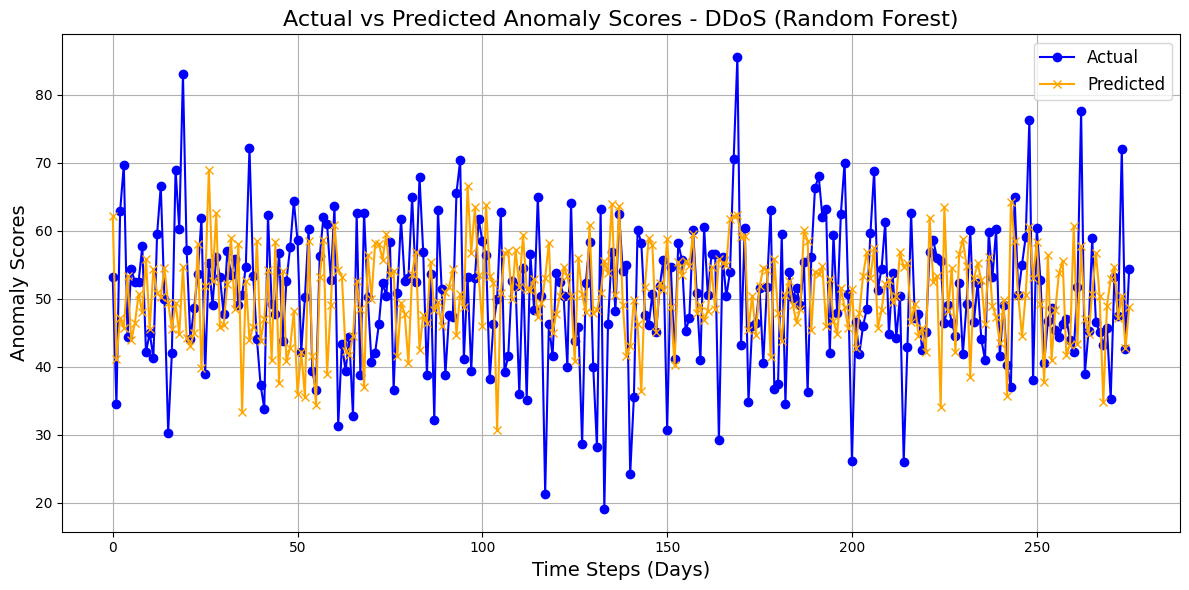

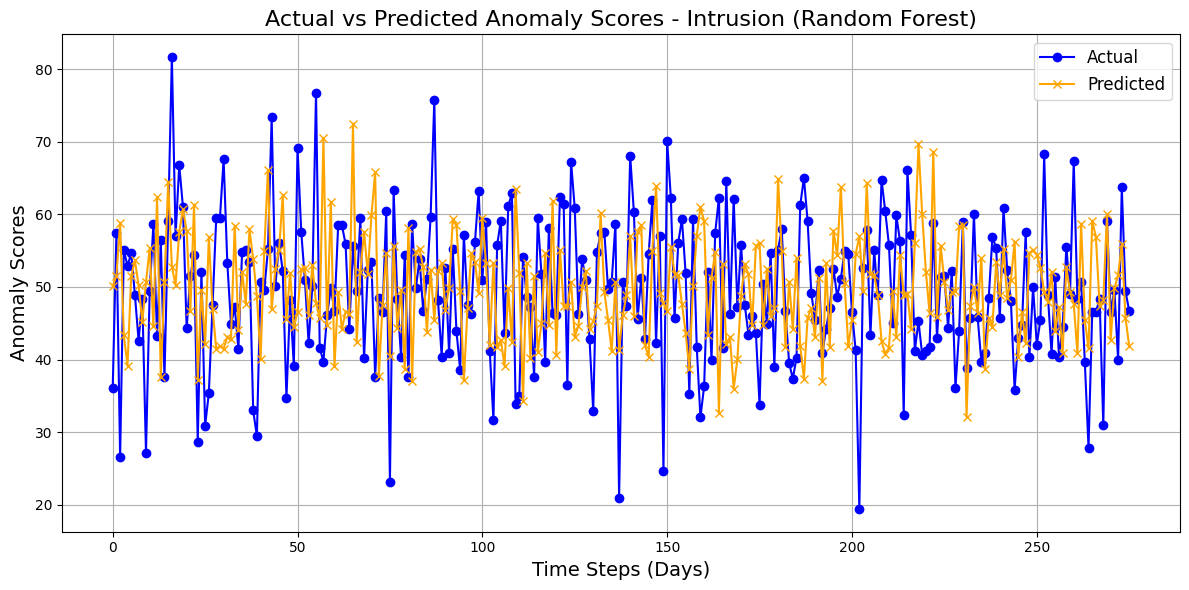

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the dataset
occurrence_matrix = pd.read_csv('daily_anomaly_score_matrix.csv', index_col=0)
relevant_attacks = occurrence_matrix.columns  # Get column names as relevant attacks

# Fill any missing values with zeros
occurrence_matrix = occurrence_matrix.fillna(0)

# Convert the date index to numerical representation (e.g., ordinal)
occurrence_matrix.index = pd.to_datetime(occurrence_matrix.index).map(pd.Timestamp.toordinal)

# Split the data into training (80%) and testing (20%) sets
train_data, test_data = train_test_split(occurrence_matrix, test_size=0.2, shuffle=False)

# Prepare inputs and outputs for Random Forest
X_train, y_train = train_data.index.values.reshape(-1, 1), train_data.values
X_test, y_test = test_data.index.values.reshape(-1, 1), test_data.values

# Initialize variables for storing predictions and errors
mae_per_attack_type_rf = {}
y_pred_rf_rescaled = []

# Train a Random Forest Regressor for each attack type
for i, attack in enumerate(relevant_attacks):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train[:, i])

    y_pred_rf = rf.predict(X_test)
    y_pred_rf_rescaled.append(y_pred_rf)

    # Calculate Mean Absolute Error (MAE) for the current attack type
    mae = mean_absolute_error(y_test[:, i], y_pred_rf)
    mae_per_attack_type_rf[attack] = mae

# Convert predictions into a numpy array for plotting
y_pred_rf_rescaled = np.column_stack(y_pred_rf_rescaled)

# Print Mean Absolute Error (MAE) for each attack type
print("Mean Absolute Error (MAE) per Attack Type - Random Forest:")
for attack_type, mae in mae_per_attack_type_rf.items():
    print(f"{attack_type}: {mae:.4f}")

# Plot actual vs predicted values for each attack type
for i, attack in enumerate(relevant_attacks):
    plt.figure(figsize=(12, 6))
    plt.plot(y_test[:, i], label='Actual', marker='o', color='blue')
    plt.plot(y_pred_rf_rescaled[:, i], label='Predicted', marker='x', color='orange')
    plt.title(f'Actual vs Predicted Anomaly Scores - {attack} (Random Forest)', fontsize=16)
    plt.xlabel('Time Steps (Days)', fontsize=14)
    plt.ylabel('Anomaly Scores', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# Load the actual values (replace with your actual data loading logic)
occurrence_matrix = pd.read_csv('daily_anomaly_score_matrix.csv', index_col=0)
y_actual = occurrence_matrix  # Assuming occurrence_matrix contains the actual values

# Assuming you have predictions from each model, ensure they are NumPy arrays
pred_lstm = np.array(y_test_rescaled_lstm)  # Replace with your LSTM predictions
pred_rf = np.array(y_pred_rf_rescaled)  # Replace with your Random Forest predictions
pred_arima = np.array(future_pred_arima_rescaled)  # Replace with your ARIMA predictions

# Ensure all predictions and actual values have the same shape
# Select the first column of each prediction for comparison and align the lengths
y_actual = y_actual.iloc[:, 0].values  # Select first attack type and convert to NumPy array

# Get the minimum length among predictions and actual values for comparison
min_len = min(len(pred_lstm), len(pred_rf), len(pred_arima), len(y_actual))

# Align the lengths of predictions and actual values by taking the last 'min_len' elements
y_actual_lstm = y_actual[len(y_actual) - min_len:]
# Select only the first element from LSTM prediction
pred_lstm = pred_lstm[0]

y_actual_rf = y_actual[len(y_actual) - min_len:]
# Select only the first element from Random Forest prediction
pred_rf = pred_rf[0]

y_actual_arima = y_actual[len(y_actual) - min_len:]
# Select only the first element from ARIMA prediction
pred_arima = pred_arima[0]

# Calculate forecast errors
error_lstm = y_actual_lstm - pred_lstm
error_rf = y_actual_rf - pred_rf
error_arima = y_actual_arima - pred_arima

# Calculate squared errors
loss_lstm = error_lstm**2
loss_rf = error_rf**2
loss_arima = error_arima**2

# Loss differentials for comparisons
d_rf_lstm = loss_lstm - loss_rf  # LSTM vs Random Forest
d_arima_lstm = loss_lstm - loss_arima  # LSTM vs ARIMA

# Function to perform Diebold-Mariano test (unchanged)
def diebold_mariano_test(d, h=1):
    n = len(d)
    d_bar = np.mean(d)
    var_d = np.var(d)

    # DM statistic calculation
    dm_statistic = d_bar / np.sqrt(var_d / n)

    # p-value calculation (two-tailed)
    from scipy.stats import norm
    p_value = 2 * (1 - norm.cdf(np.abs(dm_statistic)))

    return dm_statistic, p_value

# Perform DM test between LSTM and Random Forest
dm_stat_rf_lstm, p_value_rf_lstm = diebold_mariano_test(d_rf_lstm)

# Perform DM test between LSTM and ARIMA
dm_stat_arima_lstm, p_value_arima_lstm = diebold_mariano_test(d_arima_lstm)

print(f"DM Statistic (LSTM vs RF): {dm_stat_rf_lstm}, p-value: {p_value_rf_lstm}")
print(f"DM Statistic (LSTM vs ARIMA): {dm_stat_arima_lstm}, p-value: {p_value_arima_lstm}")

DM Statistic (LSTM vs RF): 0.8474068268696034, p-value: 0.3967684005937473
DM Statistic (LSTM vs ARIMA): 0.7323050571460401, p-value: 0.4639823933294851


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv('/content/daily_anomaly_score_matrix.csv')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  # Convert date column to datetime
data.set_index('Unnamed: 0', inplace=True)  # Set date as index

# Function to create sequences for Random Forest input
def create_sequences(data, sequence_length=10):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# Parameters
sequence_length = 10

# Dictionary to store results
results = {}

for attack_type in data.columns:
    print(f"Processing attack type: {attack_type}")

    # Normalize the data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data[[attack_type]])

    # Create sequences
    X, y = create_sequences(scaled_data, sequence_length)
    X = X.reshape(X.shape[0], -1)  # Flatten the sequences for Random Forest

    # Split into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Build Random Forest model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_rescaled = scaler.inverse_transform(y_pred.reshape(-1, 1))
    y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Compute MAE and MSE
    mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
    mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)

    # Predict next day's severity
    last_sequence = scaled_data[-sequence_length:].reshape(1, -1)
    next_day_prediction = scaler.inverse_transform(model.predict(last_sequence).reshape(-1, 1))

    # Store results
    results[attack_type] = {
        'MAE': mae,
        'MSE': mse,
        'Next Day Prediction': next_day_prediction[0, 0]
    }

# Display results
for attack_type, metrics in results.items():
    print(f"\nAttack Type: {attack_type}")
    print(f"MAE: {metrics['MAE']:.4f}")
    print(f"MSE: {metrics['MSE']:.4f}")
    print(f"Next Day Prediction: {metrics['Next Day Prediction']:.4f}")


Processing attack type: Malware


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Processing attack type: DDoS


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Processing attack type: Intrusion


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Attack Type: Malware
MAE: 7.4871
MSE: 90.7485
Next Day Prediction: 51.2831

Attack Type: DDoS
MAE: 8.4951
MSE: 111.8226
Next Day Prediction: 51.5008

Attack Type: Intrusion
MAE: 9.0555
MSE: 120.4129
Next Day Prediction: 47.9262


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import t
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv('/content/daily_anomaly_score_matrix.csv')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  # Convert date column to datetime
data.set_index('Unnamed: 0', inplace=True)  # Set date as index

# Parameters
p, d, q = 5, 1, 0  # ARIMA order
sequence_length = 10  # For LSTM and Random Forest

# Dictionary to store results
results = {}
forecast_errors = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # Placeholder for errors from each model

# Function to create sequences for LSTM and Random Forest
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

for attack_type in data.columns:
    print(f"Processing attack type: {attack_type}")

    # Extract the series
    series = data[attack_type]

    # Split into train and test sets (80% train, 20% test)
    split_idx = int(0.8 * len(series))
    train, test = series[:split_idx], series[split_idx:]

    # --- ARIMA ---
    model = ARIMA(train, order=(p, d, q))
    model_fit = model.fit()
    y_pred_arima = model_fit.forecast(steps=len(test))
    forecast_errors["ARIMA"][attack_type] = test.values - y_pred_arima

    # --- LSTM ---
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.values.reshape(-1, 1))
    X_train, y_train = create_sequences(scaled_train, sequence_length)

    model_lstm = Sequential([
        LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(X_train, y_train, epochs=20, verbose=0)

    scaled_test = scaler.transform(test.values.reshape(-1, 1))
    X_test, y_test = create_sequences(scaled_test, sequence_length)
    y_pred_lstm = model_lstm.predict(X_test)
    y_pred_lstm_rescaled = scaler.inverse_transform(y_pred_lstm)
    forecast_errors["LSTM"][attack_type] = test.values[sequence_length:] - y_pred_lstm_rescaled.flatten()

    # --- Random Forest ---
    X_train_rf, y_train_rf = X_train.reshape(X_train.shape[0], -1), y_train
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(X_train_rf, y_train_rf)
    X_test_rf = X_test.reshape(X_test.shape[0], -1)
    y_pred_rf = model_rf.predict(X_test_rf)
    y_pred_rf_rescaled = scaler.inverse_transform(y_pred_rf.reshape(-1, 1))
    forecast_errors["RandomForest"][attack_type] = test.values[sequence_length:] - y_pred_rf_rescaled.flatten()

# Function to perform Diebold-Mariano test
def diebold_mariano_test(errors_1, errors_2, h=1):
    min_len = min(len(errors_1), len(errors_2))

    # Truncate the longer array to match the length of the shorter one
    errors_1 = errors_1[:min_len]
    errors_2 = errors_2[:min_len]

    # Calculate the loss differential
    d = (errors_1**2) - (errors_2**2) # Difference in errors
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)
    dm_stat = d_mean / np.sqrt(d_var / len(d))
    p_value = 2 * (1 - t.cdf(np.abs(dm_stat), df=len(d) - 1))
    return dm_stat, p_value

# Example comparison for one attack type
attack_type_example = list(forecast_errors["LSTM"].keys())[0]
lstm_errors = forecast_errors["LSTM"][attack_type_example]
arima_errors = forecast_errors["ARIMA"][attack_type_example]
rf_errors = forecast_errors["RandomForest"][attack_type_example]

# DM Test: LSTM vs ARIMA
dm_stat_lstm_arima, p_value_lstm_arima = diebold_mariano_test(lstm_errors, arima_errors)
print(f"\nDiebold-Mariano Test (LSTM vs ARIMA) for {attack_type_example}")
print(f"DM Statistic: {dm_stat_lstm_arima:.4f}, p-value: {p_value_lstm_arima:.4f}")

# DM Test: LSTM vs Random Forest
dm_stat_lstm_rf, p_value_lstm_rf = diebold_mariano_test(lstm_errors, rf_errors)
print(f"\nDiebold-Mariano Test (LSTM vs Random Forest) for {attack_type_example}")
print(f"DM Statistic: {dm_stat_lstm_rf:.4f}, p-value: {p_value_lstm_rf:.4f}")


Processing attack type: Malware


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Processing attack type: DDoS


...

Processing attack type: Intrusion


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Diebold-Mariano Test (LSTM vs ARIMA) for Malware
DM Statistic: -4.7406, p-value: 0.0000

Diebold-Mariano Test (LSTM vs Random Forest) for Malware
DM Statistic: -0.0996, p-value: 0.9207


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import t
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv('/content/daily_anomaly_score_matrix.csv')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  # Convert date column to datetime
data.set_index('Unnamed: 0', inplace=True)  # Set date as index

# Parameters
p, d, q = 5, 1, 0  # ARIMA order
sequence_length = 20  # Increased sequence length for better pattern capture

# Dictionary to store results
results = {}
forecast_errors = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # Placeholder for errors from each model

# Function to create sequences for LSTM and Random Forest
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

for attack_type in data.columns:
    print(f"Processing attack type: {attack_type}")

    # Extract the series
    series = data[attack_type]

    # Split into train and test sets (80% train, 20% test)
    split_idx = int(0.8 * len(series))
    train, test = series[:split_idx], series[split_idx:]

    # --- ARIMA ---
    model = ARIMA(train, order=(p, d, q))
    model_fit = model.fit()
    y_pred_arima = model_fit.forecast(steps=len(test))
    forecast_errors["ARIMA"][attack_type] = test.values - y_pred_arima

    # --- LSTM ---
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.values.reshape(-1, 1))
    X_train, y_train = create_sequences(scaled_train, sequence_length)

    model_lstm = Sequential([
        LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')

    early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-5)

    model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, callbacks=[early_stopping, reduce_lr])

    scaled_test = scaler.transform(test.values.reshape(-1, 1))
    X_test, y_test = create_sequences(scaled_test, sequence_length)
    y_pred_lstm = model_lstm.predict(X_test)
    y_pred_lstm_rescaled = scaler.inverse_transform(y_pred_lstm)
    forecast_errors["LSTM"][attack_type] = test.values[sequence_length:] - y_pred_lstm_rescaled.flatten()

    # --- Random Forest ---
    X_train_rf, y_train_rf = X_train.reshape(X_train.shape[0], -1), y_train
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(X_train_rf, y_train_rf)
    X_test_rf = X_test.reshape(X_test.shape[0], -1)
    y_pred_rf = model_rf.predict(X_test_rf)
    y_pred_rf_rescaled = scaler.inverse_transform(y_pred_rf.reshape(-1, 1))
    forecast_errors["RandomForest"][attack_type] = test.values[sequence_length:] - y_pred_rf_rescaled.flatten()

# Function to perform Diebold-Mariano test
def diebold_mariano_test(errors_1, errors_2, h=1):
    min_len = min(len(errors_1), len(errors_2))

    # Truncate the longer array to match the length of the shorter one
    errors_1 = errors_1[:min_len]
    errors_2 = errors_2[:min_len]

    # Calculate the loss differential
    d = (errors_1**2) - (errors_2**2)
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)
    dm_stat = d_mean / np.sqrt(d_var / len(d))
    p_value = 2 * (1 - t.cdf(np.abs(dm_stat), df=len(d) - 1))
    return dm_stat, p_value

# Example comparison for one attack type
attack_type_example = list(forecast_errors["LSTM"].keys())[1]
lstm_errors = forecast_errors["LSTM"][attack_type_example]
arima_errors = forecast_errors["ARIMA"][attack_type_example]
rf_errors = forecast_errors["RandomForest"][attack_type_example]

# DM Test: LSTM vs ARIMA
dm_stat_lstm_arima, p_value_lstm_arima = diebold_mariano_test(lstm_errors, arima_errors)
print(f"\nDiebold-Mariano Test (LSTM vs ARIMA) for {attack_type_example}")
print(f"DM Statistic: {dm_stat_lstm_arima:.4f}, p-value: {p_value_lstm_arima:.4f}")

# DM Test: LSTM vs Random Forest
dm_stat_lstm_rf, p_value_lstm_rf = diebold_mariano_test(lstm_errors, rf_errors)
print(f"\nDiebold-Mariano Test (LSTM vs Random Forest) for {attack_type_example}")
print(f"DM Statistic: {dm_stat_lstm_rf:.4f}, p-value: {p_value_lstm_rf:.4f}")


Processing attack type: Malware


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Processing attack type: DDoS


...

Processing attack type: Intrusion


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Diebold-Mariano Test (LSTM vs ARIMA) for DDoS
DM Statistic: -0.3672, p-value: 0.7138

Diebold-Mariano Test (LSTM vs Random Forest) for DDoS
DM Statistic: -1.3659, p-value: 0.1732


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import t
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, LeakyReLU, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load data
data = pd.read_csv('/content/daily_anomaly_score_matrix.csv')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  # Convert date column to datetime
data.set_index('Unnamed: 0', inplace=True)  # Set date as index

# Parameters
p, d, q = 5, 1, 0  # ARIMA order
sequence_length = 20  # Increased sequence length for better pattern capture

# Dictionary to store results
results = {}
forecast_errors = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # Placeholder for errors from each model
mae_per_attack = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # MAE error storage
rmse_per_attack = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # RMSE error storage

# Function to create sequences for LSTM and Random Forest
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

for attack_type in data.columns:
    print(f"Processing attack type: {attack_type}")

    # Extract the series
    series = data[attack_type]

    # Split into train and test sets (80% train, 20% test)
    split_idx = int(0.8 * len(series))
    train, test = series[:split_idx], series[split_idx:]

    # --- ARIMA ---
    model = ARIMA(train, order=(p, d, q))
    model_fit = model.fit()
    y_pred_arima = model_fit.forecast(steps=len(test))
    forecast_errors["ARIMA"][attack_type] = test.values - y_pred_arima
    mae_per_attack["ARIMA"][attack_type] = mean_absolute_error(test, y_pred_arima)
    rmse_per_attack["ARIMA"][attack_type] = np.sqrt(mean_squared_error(test, y_pred_arima))

    # --- LSTM ---
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.values.reshape(-1, 1))
    X_train, y_train = create_sequences(scaled_train, sequence_length)

    model_lstm = Sequential([
        LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        BatchNormalization(),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')

    early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-5)

    model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, callbacks=[early_stopping, reduce_lr])

    scaled_test = scaler.transform(test.values.reshape(-1, 1))
    X_test, y_test = create_sequences(scaled_test, sequence_length)
    y_pred_lstm = model_lstm.predict(X_test)
    y_pred_lstm_rescaled = scaler.inverse_transform(y_pred_lstm)
    forecast_errors["LSTM"][attack_type] = test.values[sequence_length:] - y_pred_lstm_rescaled.flatten()
    mae_per_attack["LSTM"][attack_type] = mean_absolute_error(test.values[sequence_length:], y_pred_lstm_rescaled.flatten())
    rmse_per_attack["LSTM"][attack_type] = np.sqrt(mean_squared_error(test.values[sequence_length:], y_pred_lstm_rescaled.flatten()))

    # --- Random Forest ---
    X_train_rf, y_train_rf = X_train.reshape(X_train.shape[0], -1), y_train
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(X_train_rf, y_train_rf)
    X_test_rf = X_test.reshape(X_test.shape[0], -1)
    y_pred_rf = model_rf.predict(X_test_rf)
    y_pred_rf_rescaled = scaler.inverse_transform(y_pred_rf.reshape(-1, 1))
    forecast_errors["RandomForest"][attack_type] = test.values[sequence_length:] - y_pred_rf_rescaled.flatten()
    mae_per_attack["RandomForest"][attack_type] = mean_absolute_error(test.values[sequence_length:], y_pred_rf_rescaled.flatten())
    rmse_per_attack["RandomForest"][attack_type] = np.sqrt(mean_squared_error(test.values[sequence_length:], y_pred_rf_rescaled.flatten()))

# Function to perform Diebold-Mariano test
def diebold_mariano_test(errors_1, errors_2, h=1):
    min_len = min(len(errors_1), len(errors_2))

    # Truncate the longer array to match the length of the shorter one
    errors_1 = errors_1[:min_len]
    errors_2 = errors_2[:min_len]

    # Calculate the loss differential
    d = (errors_1**2) - (errors_2**2)
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)
    dm_stat = d_mean / np.sqrt(d_var / len(d))
    p_value = 2 * (1 - t.cdf(np.abs(dm_stat), df=len(d) - 1))
    return dm_stat, p_value

# Example comparison for one attack type
attack_type_example = list(forecast_errors["LSTM"].keys())[1]
lstm_errors = forecast_errors["LSTM"][attack_type_example]
arima_errors = forecast_errors["ARIMA"][attack_type_example]
rf_errors = forecast_errors["RandomForest"][attack_type_example]

# DM Test: LSTM vs ARIMA
dm_stat_lstm_arima, p_value_lstm_arima = diebold_mariano_test(lstm_errors, arima_errors)
print(f"\nDiebold-Mariano Test (LSTM vs ARIMA) for {attack_type_example}")
print(f"DM Statistic: {dm_stat_lstm_arima:.4f}, p-value: {p_value_lstm_arima:.4f}")

# DM Test: LSTM vs Random Forest
dm_stat_lstm_rf, p_value_lstm_rf = diebold_mariano_test(lstm_errors, rf_errors)
print(f"\nDiebold-Mariano Test (LSTM vs Random Forest) for {attack_type_example}")
print(f"DM Statistic: {dm_stat_lstm_rf:.4f}, p-value: {p_value_lstm_rf:.4f}")

# Print the MAE and RMSE across all attack types
print("\nMean Absolute Error (MAE) per Attack Type:")
for model in ['ARIMA', 'LSTM', 'RandomForest']:
    print(f"\n{model}:")
    for attack_type in data.columns:
        print(f"{attack_type}: {mae_per_attack[model][attack_type]:.4f}")

print("\nRoot Mean Squared Error (RMSE) per Attack Type:")
for model in ['ARIMA', 'LSTM', 'RandomForest']:
    print(f"\n{model}:")
    for attack_type in data.columns:
        print(f"{attack_type}: {rmse_per_attack[model][attack_type]:.4f}")


Processing attack type: Malware


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Processing attack type: DDoS


...

Processing attack type: Intrusion


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Diebold-Mariano Test (LSTM vs ARIMA) for DDoS
DM Statistic: -0.4550, p-value: 0.6495

Diebold-Mariano Test (LSTM vs Random Forest) for DDoS
DM Statistic: -1.8543, p-value: 0.0648

Mean Absolute Error (MAE) per Attack Type:

ARIMA:
Malware: 10.9200
DDoS: 8.2864
Intrusion: 7.9777

LSTM:
Malware: 7.8882
DDoS: 8.0436
Intrusion: 7.7790

RandomForest:
Malware: 7.9839
DDoS: 8.2229
Intrusion: 7.8866

Root Mean Squared Error (RMSE) per Attack Type:

ARIMA:
Malware: 13.2780
DDoS: 10.5245
Intrusion: 10.0809

LSTM:
Malware: 9.9808
DDoS: 10.2212
Intrusion: 9.7728

RandomForest:
Malware: 10.1202
DDoS: 10.4843
Intrusion: 9.9658


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import t
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler

# Load data
data = pd.read_csv('/content/daily_anomaly_score_matrix.csv')
data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])  # Convert date column to datetime
data.set_index('Unnamed: 0', inplace=True)  # Set date as index

# Parameters
p, d, q = 5, 1, 0  # ARIMA order
sequence_length = 20  # Increased sequence length for better pattern capture

# Dictionary to store results
results = {}
forecast_errors = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # Placeholder for errors from each model
mae_per_attack = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # MAE error storage
rmse_per_attack = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # RMSE error storage
mape_per_attack = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # MAPE error storage
r2_per_attack = {"ARIMA": {}, "LSTM": {}, "RandomForest": {}}  # R² error storage

# Function to create sequences for LSTM and Random Forest
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

# Function to perform Diebold-Mariano test
def diebold_mariano_test(errors_1, errors_2, h=1):
    min_len = min(len(errors_1), len(errors_2))

    # Truncate the longer array to match the length of the shorter one
    errors_1 = errors_1[:min_len]
    errors_2 = errors_2[:min_len]

    # Calculate the loss differential
    d = (errors_1**2) - (errors_2**2)
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)
    dm_stat = d_mean / np.sqrt(d_var / len(d))
    p_value = 2 * (1 - t.cdf(np.abs(dm_stat), df=len(d) - 1))
    return dm_stat, p_value

# Main loop for all attack types
for attack_type in data.columns:
    print(f"Processing attack type: {attack_type}")

    # Extract the series
    series = data[attack_type]

    # Split into train and test sets (80% train, 20% test)
    split_idx = int(0.8 * len(series))
    train, test = series[:split_idx], series[split_idx:]

    # --- ARIMA ---
    model = ARIMA(train, order=(p, d, q))
    model_fit = model.fit()
    y_pred_arima = model_fit.forecast(steps=len(test))
    forecast_errors["ARIMA"][attack_type] = test.values - y_pred_arima
    mae_per_attack["ARIMA"][attack_type] = mean_absolute_error(test, y_pred_arima)
    rmse_per_attack["ARIMA"][attack_type] = np.sqrt(mean_squared_error(test, y_pred_arima))
    mape_per_attack["ARIMA"][attack_type] = mean_absolute_percentage_error(test, y_pred_arima)
    r2_per_attack["ARIMA"][attack_type] = r2_score(test, y_pred_arima)

    # --- LSTM ---
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train.values.reshape(-1, 1))
    X_train, y_train = create_sequences(scaled_train, sequence_length)

    model_lstm = Sequential([
        LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        BatchNormalization(),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')

    early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-5)

    model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0, callbacks=[early_stopping, reduce_lr])

    scaled_test = scaler.transform(test.values.reshape(-1, 1))
    X_test, y_test = create_sequences(scaled_test, sequence_length)
    y_pred_lstm = model_lstm.predict(X_test)
    y_pred_lstm_rescaled = scaler.inverse_transform(y_pred_lstm)
    forecast_errors["LSTM"][attack_type] = test.values[sequence_length:] - y_pred_lstm_rescaled.flatten()
    mae_per_attack["LSTM"][attack_type] = mean_absolute_error(test.values[sequence_length:], y_pred_lstm_rescaled.flatten())
    rmse_per_attack["LSTM"][attack_type] = np.sqrt(mean_squared_error(test.values[sequence_length:], y_pred_lstm_rescaled.flatten()))
    mape_per_attack["LSTM"][attack_type] = mean_absolute_percentage_error(test.values[sequence_length:], y_pred_lstm_rescaled.flatten())
    r2_per_attack["LSTM"][attack_type] = r2_score(test.values[sequence_length:], y_pred_lstm_rescaled.flatten())

    # --- Random Forest ---
    X_train_rf, y_train_rf = X_train.reshape(X_train.shape[0], -1), y_train
    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(X_train_rf, y_train_rf)
    X_test_rf = X_test.reshape(X_test.shape[0], -1)
    y_pred_rf = model_rf.predict(X_test_rf)
    y_pred_rf_rescaled = scaler.inverse_transform(y_pred_rf.reshape(-1, 1))
    forecast_errors["RandomForest"][attack_type] = test.values[sequence_length:] - y_pred_rf_rescaled.flatten()
    mae_per_attack["RandomForest"][attack_type] = mean_absolute_error(test.values[sequence_length:], y_pred_rf_rescaled.flatten())
    rmse_per_attack["RandomForest"][attack_type] = np.sqrt(mean_squared_error(test.values[sequence_length:], y_pred_rf_rescaled.flatten()))
    mape_per_attack["RandomForest"][attack_type] = mean_absolute_percentage_error(test.values[sequence_length:], y_pred_rf_rescaled.flatten())
    r2_per_attack["RandomForest"][attack_type] = r2_score(test.values[sequence_length:], y_pred_rf_rescaled.flatten())

# Perform Diebold-Mariano test across all attack types
for attack_type in data.columns:
    lstm_errors = forecast_errors["LSTM"][attack_type]
    arima_errors = forecast_errors["ARIMA"][attack_type]
    rf_errors = forecast_errors["RandomForest"][attack_type]

    # DM Test: LSTM vs ARIMA
    dm_stat_lstm_arima, p_value_lstm_arima = diebold_mariano_test(lstm_errors, arima_errors)
    print(f"\nDiebold-Mariano Test (LSTM vs ARIMA) for {attack_type}")
    print(f"DM Statistic: {dm_stat_lstm_arima:.4f}, p-value: {p_value_lstm_arima:.4f}")

    # DM Test: LSTM vs Random Forest
    dm_stat_lstm_rf, p_value_lstm_rf = diebold_mariano_test(lstm_errors, rf_errors)
    print(f"Diebold-Mariano Test (LSTM vs Random Forest) for {attack_type}")
    print(f"DM Statistic: {dm_stat_lstm_rf:.4f}, p-value: {p_value_lstm_rf:.4f}")

# Print the MAE, RMSE, MAPE, R² across all attack types
print("\nMean Absolute Error (MAE) per Attack Type:")
for model in ['ARIMA', 'LSTM', 'RandomForest']:
    print(f"\n{model}:")
    for attack_type in data.columns:
        print(f"{attack_type}: {mae_per_attack[model][attack_type]:.4f}")

print("\nRoot Mean Squared Error (RMSE) per Attack Type:")
for model in ['ARIMA', 'LSTM', 'RandomForest']:
    print(f"\n{model}:")
    for attack_type in data.columns:
        print(f"{attack_type}: {rmse_per_attack[model][attack_type]:.4f}")

print("\nMean Absolute Percentage Error (MAPE) per Attack Type:")
for model in ['ARIMA', 'LSTM', 'RandomForest']:
    print(f"\n{model}:")
    for attack_type in data.columns:
        print(f"{attack_type}: {mape_per_attack[model][attack_type]:.4f}")

print("\nR-Squared (R²) per Attack Type:")
for model in ['ARIMA', 'LSTM', 'RandomForest']:
    print(f"\n{model}:")
    for attack_type in data.columns:
        print(f"{attack_type}: {r2_per_attack[model][attack_type]:.4f}")


Processing attack type: Malware


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Processing attack type: DDoS


...

Processing attack type: Intrusion


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsm

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Diebold-Mariano Test (LSTM vs ARIMA) for Malware
DM Statistic: -4.7125, p-value: 0.0000
Diebold-Mariano Test (LSTM vs Random Forest) for Malware
DM Statistic: -1.2281, p-value: 0.2205

Diebold-Mariano Test (LSTM vs ARIMA) for DDoS
DM Statistic: -0.4530, p-value: 0.6509
Diebold-Mariano Test (LSTM vs Random Forest) for DDoS
DM Statistic: -1.8036, p-value: 0.0725

Diebold-Mariano Test (LSTM vs ARIMA) for Intrusion
DM Statistic: -0.5450, p-value: 0.5862
Diebold-Mariano Test (LSTM vs Random Forest) for Intrusion
DM Statistic: -1.6271, p-value: 0.1050

Mean Absolute Error (MAE) per Attack Type:

ARIMA:
Malware: 10.9200
DDoS: 8.2864
Intrusion: 7.9777

LSTM:
Malware: 7.9029
DDoS: 8.0504
Intrusion: 7.7908

RandomForest:
Malware: 7.9839
DDoS: 8.2229
Intrusion: 7.8866

Root Mean Squared Error (RMSE) per Attack Type:

ARIMA:
Malware: 13.2780
DDoS: 10.5245
Intrusion: 10.0809

LSTM:
Malware: 9.9805
DDoS: 10.2227
Intrusion: 9.7904

RandomForest:
Malware: 10.1202
DDoS: 10.4843
Intrusion: 9.9658

Mean

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

class CybersecurityPredictionModel:
    def __init__(self, file_path):
        # Load the dataset
        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])

        # Identify relevant attack types
        self.relevant_attacks = self.df['Attack Type'].value_counts().head(10).index.tolist()

        # Prepare GNN and LSTM components
        self.graph = None
        self.node_features = None
        self.scaler = MinMaxScaler()
        self.lstm_model = None
        self.n_steps = 30

        self.prepare_data()
        self.train_lstm()

    def prepare_data(self):
        """
        Preprocess and prepare data for GNN and LSTM.
        """
        # One-hot encode attack types for anomaly scores
        attack_dummies = pd.get_dummies(self.df['Attack Type'])[self.relevant_attacks]
        self.df['Anomaly Scores'] = attack_dummies.max(axis=1)

        # Create a graph for GNN
        self.graph = nx.Graph()
        states = self.df['Destination State'].unique()

        # Add nodes
        for state in states:
            self.graph.add_node(state)

        # Add edges based on similarity of attack patterns
        for i, state1 in enumerate(states):
            for state2 in states[i+1:]:
                state_rows1 = self.df[self.df['Destination State'] == state1]
                state_rows2 = self.df[self.df['Destination State'] == state2]

            # Ensure vec1 and vec2 have the same length:
                min_len = min(len(state_rows1), len(state_rows2))
                vec1 = state_rows1['Anomaly Scores'].values[:min_len]
                vec2 = state_rows2['Anomaly Scores'].values[:min_len]

                if len(vec1) > 0 and len(vec2) > 0:
                    similarity = cosine_similarity([vec1], [vec2])[0, 0]
                    self.graph.add_edge(state1, state2, weight=similarity)

    def train_gnn(self):
        """
        Train a simplified GNN by propagating node features based on edge weights.
        """
        # Initialize node features (mean anomaly scores per state)
        self.node_features = {
            state: self.df[self.df['Destination State'] == state]['Anomaly Scores'].mean()
            for state in self.graph.nodes
        }

        # Propagate features across edges (weighted mean)
        for _ in range(5):  # 5 iterations of propagation
            new_features = {}
            for node in self.graph.nodes:
                neighbors = list(self.graph.neighbors(node))
                if neighbors:
                    weights = np.array([self.graph[node][neighbor]['weight'] for neighbor in neighbors])
                    features = np.array([self.node_features[neighbor] for neighbor in neighbors])
                    new_features[node] = np.average(features, weights=weights)
                else:
                    new_features[node] = self.node_features[node]
            self.node_features.update(new_features)

    def train_lstm(self):
        """
        Train an LSTM model on anomaly scores for the top states.
        """
        # Prepare daily anomaly scores
        daily_scores = self.df.groupby([self.df['Timestamp'].dt.date, 'Attack Type'])['Anomaly Scores'].mean().unstack(fill_value=0)
        daily_scores = daily_scores[self.relevant_attacks]
        daily_scores_smoothed = daily_scores.rolling(window=3, min_periods=1).mean()

        # Normalize the data
        scaled_scores = self.scaler.fit_transform(daily_scores_smoothed)

        # Create sequences for LSTM
        sequences, targets = [], []
        for i in range(self.n_steps, len(scaled_scores)):
            sequences.append(scaled_scores[i-self.n_steps:i])
            targets.append(scaled_scores[i])

        sequences, targets = np.array(sequences), np.array(targets)

        # Build and train the LSTM model
        self.lstm_model = Sequential([
            LSTM(50, activation='relu', input_shape=(self.n_steps, sequences.shape[2]), return_sequences=False),
            Dense(targets.shape[1])
        ])

        self.lstm_model.compile(optimizer='adam', loss='mse')
        self.lstm_model.fit(sequences, targets, epochs=10, batch_size=32, verbose=1)

    def predict_lstm_anomalies(self, state_name):
        """
        Predict anomaly scores for a specific state using LSTM.
        """
        # Filter data for the specific state (as destination)
        state_data = self.df[self.df['Destination State'] == state_name]

        if state_data.empty:
            print(f"No data found for state: {state_name}")
            return None

        # Group by attack type and calculate daily anomaly scores
        state_daily = state_data.groupby([state_data['Timestamp'].dt.date, 'Attack Type'])['Anomaly Scores'].mean().unstack(fill_value=0)
        state_daily = state_daily.reindex(columns=self.relevant_attacks, fill_value=0)

        # Smooth the data
        state_smoothed = state_daily.rolling(window=3, min_periods=1).mean()

        # Normalize the data
        state_scaled = self.scaler.transform(state_smoothed)

        # Prepare input for LSTM prediction
        if len(state_scaled) >= self.n_steps:
            last_sequence = state_scaled[-self.n_steps:]
            future_pred_scaled = self.lstm_model.predict(last_sequence[np.newaxis, :, :])

            # Inverse transform the prediction
            future_pred_rescaled = self.scaler.inverse_transform(future_pred_scaled)[0]

            # Clip negative values to zero
            future_pred_rescaled = np.clip(future_pred_rescaled, 0, None).round()

            # Create a DataFrame for easy reading
            future_df = pd.DataFrame([future_pred_rescaled], columns=self.relevant_attacks, index=['Next Day'])

            print(f"\nLSTM Anomaly Score Predictions for {state_name}:")
            print(future_df)

            return future_df
        else:
            print(f"Insufficient historical data for state: {state_name}")
            return None

    def visualize_predictions(self, state_name):
        """
        Visualize GNN features and LSTM predictions for a specific state.
        """
        # GNN Features
        print(f"\nGNN Features for {state_name}: {self.node_features.get(state_name, 'Not Found')}")

        # LSTM Predictions
        self.predict_lstm_anomalies(state_name)

if __name__ == "__main__":
    # Initialize the model
    model = CybersecurityPredictionModel('cybersecurity_attacks_with_states.csv')

    # Train the GNN
    model.train_gnn()

    # Example state prediction
    state_name = "Maharashtra"  # Replace with a state from your dataset

    # Visualize predictions for the state
    model.visualize_predictions(state_name)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0000e+00
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0000e+00
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0000e+00
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0000e+00
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0000e+00
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0000e+00
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0000e+00
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0000e+00
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0000e+00
Epoch 10/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0000e+00

GNN Features for Maharashtra: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step

LSTM Anomaly Score Predictions for Maharashtra:
          DDoS  Malware  Intrusion
Next Day   1.0      1.0        1.0


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

class ImprovedCybersecurityPredictionModel:
    def __init__(self, file_path):
        # Load and preprocess the dataset
        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])

        # More robust feature engineering
        self.prepare_features()

        # Initialize models and scalers
        self.state_models = {}
        self.state_scalers = {}

        # Advanced hyperparameters
        self.n_steps = 30
        self.n_features = None

    def prepare_features(self):
        """
        Enhanced feature engineering for cybersecurity data.
        """
        # Create more comprehensive features
        self.df['Hour'] = self.df['Timestamp'].dt.hour
        self.df['Day_of_Week'] = self.df['Timestamp'].dt.dayofweek

        # Enhanced anomaly scoring
        attack_severity_map = {
            'Low': 0.3,
            'Medium': 0.6,
            'High': 1.0,
            'Critical': 1.5
        }
        self.df['Attack_Severity_Score'] = self.df['Severity Level'].map(attack_severity_map).fillna(0.5)

        # Create a composite anomaly score
        self.df['Composite_Anomaly_Score'] = (
            self.df['Anomaly Scores'] *
            self.df['Attack_Severity_Score'] *
            (1 + np.log1p(self.df['Packet Length']) / 10)
        )

    def prepare_state_data(self, state_name):
        """
        Prepare time series data for a specific state with robust preprocessing.
        """
        # Filter data for the specific state
        state_data = self.df[self.df['Destination State'] == state_name]

        # Group by timestamp and aggregate features
        daily_data = state_data.groupby(pd.Grouper(key='Timestamp', freq='D')).agg({
            'Composite_Anomaly_Score': 'mean',
            'Hour': 'count',  # Using this as a proxy for daily activity volume
            'Attack Type': lambda x: len(x.unique())  # Diversity of attack types
        }).reset_index()

        # Sort by timestamp
        daily_data = daily_data.sort_values('Timestamp')

        # Fill NaN values with 0 (or other appropriate strategy)
        daily_data.fillna(0, inplace=True)  # Handle potential NaNs from aggregation

        return daily_data

    def create_sequences(self, data, n_steps):
        """
        Create sequences for LSTM input with multiple features.
        """
        X, y = [], []
        features = ['Composite_Anomaly_Score', 'Hour', 'Attack Type']

        for i in range(len(data) - n_steps):
            X.append(data[features].iloc[i:i+n_steps].values)
            y.append(data['Composite_Anomaly_Score'].iloc[i+n_steps])

        return np.array(X), np.array(y)

    def train_state_model(self, state_name):
        """
        Train an LSTM model for a specific state with advanced techniques.
        """
        # Prepare state-specific data
        state_data = self.prepare_state_data(state_name)

        # Create sequences
        if len(state_data) <= self.n_steps:
            print(f"Insufficient data for state {state_name}")
            return None

        # Create sequences
        X, y = self.create_sequences(state_data, self.n_steps)

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
        X_test_scaled = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

        # Build LSTM model with dropout and regularization
        model = Sequential([
            LSTM(64, activation='relu', input_shape=(self.n_steps, X_train.shape[2]), return_sequences=True),
            Dropout(0.2),
            LSTM(32, activation='relu'),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])

        model.compile(optimizer='adam', loss='mse', metrics=['mae'])

        # Early stopping
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        # Train model
        model.fit(
            X_train_scaled, y_train,
            validation_split=0.2,
            epochs=50,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )

        # Evaluate model
        y_pred = model.predict(X_test_scaled).flatten()
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        print(f"\nModel Performance for {state_name}:")
        print(f"Mean Squared Error: {mse}")
        print(f"Mean Absolute Error: {mae}")

        # Store model and scaler
        self.state_models[state_name] = model
        self.state_scalers[state_name] = scaler

        return model

    def predict_state_anomalies(self, state_name):
        """
        Predict anomalies for a specific state using its trained model.
        """
        if state_name not in self.state_models:
            print(f"No model trained for state: {state_name}")
            return None

        # Prepare latest data
        state_data = self.prepare_state_data(state_name)

        if len(state_data) < self.n_steps:
            print(f"Insufficient data for prediction in {state_name}")
            return None

        # Get the last sequence
        latest_sequence = state_data.iloc[-self.n_steps:]

        # Create sequence
        X, _ = self.create_sequences(state_data, self.n_steps)
        latest_X = X[-1].reshape(1, self.n_steps, X.shape[2])

        # Scale sequence
        scaler = self.state_scalers[state_name]
        X_scaled = scaler.transform(latest_X.reshape(-1, latest_X.shape[-1])).reshape(latest_X.shape)

        # Predict
        prediction = self.state_models[state_name].predict(X_scaled)[0, 0]

        print(f"\nAnomaly Prediction for {state_name}:")
        print(f"Next Day Predicted Anomaly Score: {prediction:.4f}")

        return prediction

    def train_and_predict_multiple_states(self, states=None):
        """
        Train models and predict for multiple states.
        """
        if states is None:
            states = self.df['Destination State'].unique()[:5]  # Default to first 5 states

        predictions = {}
        for state in states:
            print(f"\nProcessing state: {state}")
            # Train state model
            model = self.train_state_model(state)

            if model:
                # Predict anomalies
                prediction = self.predict_state_anomalies(state)
                predictions[state] = prediction

        return predictions

if __name__ == "__main__":
    # Initialize and run the model
    model = ImprovedCybersecurityPredictionModel('cybersecurity_attacks_with_states.csv')

    # Train and predict for multiple states
    model.train_and_predict_multiple_states()


Processing state: Sikkim


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step

Model Performance for Sikkim:
Mean Squared Error: 1409.5722881994152
Mean Absolute Error: 31.24827470063454
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

Anomaly Prediction for Sikkim:
Next Day Predicted Anomaly Score: 28.4316

Processing state: Nagaland


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step

Model Performance for Nagaland:
Mean Squared Error: 1586.3805807072308
Mean Absolute Error: 31.545740248489427
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

Anomaly Prediction for Nagaland:
Next Day Predicted Anomaly Score: 32.2492

Processing state: Rajasthan


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step

Model Performance for Rajasthan:
Mean Squared Error: 1592.262864140788
Mean Absolute Error: 32.85450415739364
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Anomaly Prediction for Rajasthan:
Next Day Predicted Anomaly Score: 36.6478

Processing state: Tripura


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

Model Performance for Tripura:
Mean Squared Error: 1609.9185919904266
Mean Absolute Error: 32.816690946986434
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Anomaly Prediction for Tripura:
Next Day Predicted Anomaly Score: 32.8212

Processing state: Meghalaya


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

Model Performance for Meghalaya:
Mean Squared Error: 1603.7510051365732
Mean Absolute Error: 32.87296981877658
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Anomaly Prediction for Meghalaya:
Next Day Predicted Anomaly Score: 33.6897


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

class StatewiseLSTMPredictor:
    def __init__(self, file_path):
        np.random.seed(42)
        tf.random.set_seed(42)

        # Load data
        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])
        self.df.dropna(inplace=True)

        # Preprocess data
        self.preprocess_data()

    def preprocess_data(self):
        """Prepare the dataset for modeling."""
        self.df['Hour'] = self.df['Timestamp'].dt.hour
        self.df['Day_of_Week'] = self.df['Timestamp'].dt.dayofweek

        severity_map = {'Low': 0.3, 'Medium': 0.6, 'High': 1.0, 'Critical': 1.5}
        self.df['Severity_Score'] = self.df['Severity Level'].map(severity_map).fillna(0.5)

        self.df['Enhanced_Anomaly_Score'] = (
            self.df['Anomaly Scores'] * self.df['Severity_Score'] *
            (1 + np.log1p(self.df['Packet Length']) / 10)
        )

    def prepare_sequences(self, data, n_steps=7):
        """Generate sequences for LSTM training."""
        X, y = [], []
        for i in range(len(data) - n_steps):
            X.append(data[i:i + n_steps])
            y.append(data[i + n_steps])
        return np.array(X), np.array(y)

    def train_state_model(self, state, attack_type, column, n_steps=7):
        """Train an LSTM model for a specific state, attack type, and column."""
        filtered_df = self.df[
            (self.df[column] == state) &
            (self.df['Attack Type'] == attack_type)
        ]

        if len(filtered_df) < n_steps:
            print(f"Not enough data for state: {state}, attack type: {attack_type}, column: {column}")
            return None

        daily_data = filtered_df.groupby(
            pd.Grouper(key='Timestamp', freq='D')
        )['Enhanced_Anomaly_Score'].mean().dropna()

        if len(daily_data) < n_steps:
            print(f"Not enough daily aggregated data for state: {state}, attack type: {attack_type}, column: {column}")
            return None

        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(daily_data.values.reshape(-1, 1))

        X, y = self.prepare_sequences(scaled_data, n_steps)
        if len(X) == 0:
            print(f"Unable to create sequences for state: {state}, attack type: {attack_type}, column: {column}")
            return None

        if len(X) < 2:  # At least 2 data points needed for train/test split
            print(f"Not enough data for train_test_split: state: {state}, attack type: {attack_type}, column: {column}")
            return None  # Or handle differently (e.g., skip or use all data for training)


        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, shuffle=False
        )

        model = Sequential([
            LSTM(64, activation='relu', return_sequences=True, input_shape=(n_steps, 1)),
            Dropout(0.3),
            LSTM(32, activation='relu'),
            Dropout(0.2),
            Dense(1)
        ])

        model.compile(optimizer='adam', loss='mse', metrics=['mae'])

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

        if len(X_train) <= 1:
            print(f"Not enough data for validation split: state: {state}, attack type: {attack_type}, column: {column}")
            return None  # Skip training for this state/attack type/column combination


        model.fit(
            X_train, y_train, validation_split=0.2, epochs=100, batch_size=32,
            callbacks=[early_stop, reduce_lr], verbose=0
        )

        _, mae = model.evaluate(X_test, y_test, verbose=0)
        print(f"State: {state}, Attack Type: {attack_type}, Column: {column}, MAE: {mae}")

        return model, scaler

    def predict_statewise(self, state, attack_type, model, scaler, column, n_steps=7):
        """Generate predictions for a specific state, attack type, and column."""
        filtered_df = self.df[
            (self.df[column] == state) &
            (self.df['Attack Type'] == attack_type)
        ]

        daily_data = filtered_df.groupby(
            pd.Grouper(key='Timestamp', freq='D')
        )['Enhanced_Anomaly_Score'].mean().dropna()

        if len(daily_data) < n_steps:
            print(f"Insufficient data for predictions: state: {state}, attack type: {attack_type}, column: {column}")
            return None

        scaled_data = scaler.transform(daily_data.values.reshape(-1, 1))
        X, _ = self.prepare_sequences(scaled_data, n_steps)
        if len(X) == 0:
            print(f"Cannot create sequences for predictions: state: {state}, attack type: {attack_type}, column: {column}")
            return None

        latest_sequence = X[-1].reshape(1, X.shape[1], X.shape[2])
        prediction = model.predict(latest_sequence, verbose=0)[0, 0]

        return scaler.inverse_transform([[prediction]])[0, 0]

    def train_and_predict(self, states, attack_types):
        """Train and predict for multiple states and attack types for both source and destination."""
        results = {}

        for column in ['Source State', 'Destination State']:
            print(f"\nProcessing column: {column}")
            results[column] = {}

            for state in states:
                results[column][state] = {}
                for attack_type in attack_types:
                    print(f"Training for State: {state}, Attack Type: {attack_type}, Column: {column}")
                    # Call train_state_model to get model and scaler
                    output = self.train_state_model(state, attack_type, column)

                    # Check if train_state_model returned valid values
                    if output is not None:  # Check if output is not None
                        model, scaler = output

                        if model and scaler:
                            prediction = self.predict_statewise(state, attack_type, model, scaler, column)
                            results[column][state][attack_type] = prediction
                        else:
                            results[column][state][attack_type] = None
                    else:
                        print(f"Skipping prediction for State: {state}, Attack Type: {attack_type} due to insufficient data.")
                        results[column][state][attack_type] = None


        return results

if __name__ == "__main__":
    file_path = '/content/cybersecurity_attacks_with_states.csv'
    predictor = StatewiseLSTMPredictor(file_path)

    states = predictor.df['Destination State'].unique()
    attack_types = predictor.df['Attack Type'].unique()

    predictions = predictor.train_and_predict(states, attack_types)

    for column, column_preds in predictions.items():
        print(f"\nColumn: {column}")
        for state, attack_preds in column_preds.items():
            print(f"\nState: {state}")
            for attack, pred in attack_preds.items():
                print(f"{attack}: {pred}")


Processing column: Source State
Training for State: Rajasthan, Attack Type: DDoS, Column: Source State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Rajasthan, Attack Type: DDoS, Column: Source State, MAE: 0.2656364440917969
Training for State: Rajasthan, Attack Type: Intrusion, Column: Source State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Rajasthan, Attack Type: Intrusion, Column: Source State, MAE: 0.07777485996484756
Training for State: Rajasthan, Attack Type: Malware, Column: Source State


...

State: Mizoram, Attack Type: DDoS, Column: Destination State, MAE: 0.21039600670337677
Training for State: Mizoram, Attack Type: Intrusion, Column: Destination State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Mizoram, Attack Type: Intrusion, Column: Destination State, MAE: 0.38797006011009216
Training for State: Mizoram, Attack Type: Malware, Column: Destination State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Mizoram, Attack Type: Malware, Column: Destination State, MAE: 0.11851073801517487

Column: Source State

State: Rajasthan
DDoS: 32.1831573798064
Intrusion: 35.41021182897163
Malware: 43.32551130199573

State: Andhra Pradesh
DDoS: 41.78124051624644
Intrusion: 54.98438080354786
Malware: 42.54800653764051

State: Kerala
DDoS: None
Intrusion: None
Malware: None

State: Gujarat
DDoS: 14.68164094898759
Intrusion: 18.638066520627948
Malware: 15.023852821623802

State: Sikkim
DDoS: None
Intrusion: None
Malware: None

State: Odisha
DDoS: 43.47658852106061
Intrusion: 16.456488076562717
Malware: None

State: Nagaland
DDoS: None
Intrusion: None
Malware: None

State: Manipur
DDoS: None
Intrusion: None
Malware: None

State: Maharashtra
DDoS: 19.318099041435186
Intrusion: 49.66024381053558
Malware: 85.97349636342781

State: Chhattisgarh
DDoS: None
Intrusion: 38.83280315111785
Malware: None

State: West Bengal
DDoS: 53.364122350573524
Intrusion: 50.54823779261762
Malware: 51.76227756629073

St

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
!pip install tabulate
from tabulate import tabulate

class StatewiseLSTMPredictor:
    def __init__(self, file_path):
        np.random.seed(42)
        tf.random.set_seed(42)

        # Load data
        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])
        self.df.dropna(inplace=True)

        # Preprocess data
        self.preprocess_data()

    def preprocess_data(self):
        """Prepare the dataset for modeling."""
        self.df['Hour'] = self.df['Timestamp'].dt.hour
        self.df['Day_of_Week'] = self.df['Timestamp'].dt.dayofweek

        severity_map = {'Low': 0.3, 'Medium': 0.6, 'High': 1.0, 'Critical': 1.5}
        self.df['Severity_Score'] = self.df['Severity Level'].map(severity_map).fillna(0.5)

        self.df['Enhanced_Anomaly_Score'] = (
            self.df['Anomaly Scores'] * self.df['Severity_Score'] *
            (1 + np.log1p(self.df['Packet Length']) / 10)
        )

    def prepare_sequences(self, data, n_steps=7):
        """Generate sequences for LSTM training."""
        X, y = [], []
        for i in range(len(data) - n_steps):
            X.append(data[i:i + n_steps])
            y.append(data[i + n_steps])
        return np.array(X), np.array(y)

    def train_state_model(self, state, attack_type, column, n_steps=7):
      filtered_df = self.df[
          (self.df[column] == state) &
          (self.df['Attack Type'] == attack_type)
      ]

      if len(filtered_df) < n_steps:
          print(f"Not enough data for state: {state}, attack type: {attack_type}, column: {column}")
          return None

      daily_data = filtered_df.groupby(
          pd.Grouper(key='Timestamp', freq='D')
      )['Enhanced_Anomaly_Score'].mean().dropna()

      if len(daily_data) < n_steps:
          print(f"Not enough daily aggregated data for state: {state}, attack type: {attack_type}, column: {column}")
          return None

      scaler = MinMaxScaler()
      scaled_data = scaler.fit_transform(daily_data.values.reshape(-1, 1))

      X, y = self.prepare_sequences(scaled_data, n_steps)
      if len(X) == 0:
          print(f"Unable to create sequences for state: {state}, attack type: {attack_type}, column: {column}")
          return None

    # Checking if enough data is available for train_test_split and validation split
      if len(X) < 2:  # At least 2 samples needed for splitting
          print(f"Not enough data for train_test_split and validation split: state: {state}, attack type: {attack_type}, column: {column}")
          return None

      X_train, X_test, y_train, y_test = train_test_split(
          X, y, test_size=0.2, shuffle=False
      )
    # Check if there is enough data for the training set and validation set
      if len(X_train) * 0.2 < 2:  # Make sure validation_split has at least 2 samples
          print(f"Not enough data for validation split: state: {state}, attack type: {attack_type}, column: {column}")
          return None


      model = Sequential([
          LSTM(64, activation='relu', return_sequences=True, input_shape=(n_steps, 1)),
          Dropout(0.3),
          LSTM(32, activation='relu'),
          Dropout(0.2),
          Dense(1)
      ])

      model.compile(optimizer='adam', loss='mse', metrics=['mae'])

      early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
      reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

      model.fit(
          X_train, y_train, validation_split=0.2, epochs=100, batch_size=32,
          callbacks=[early_stop, reduce_lr], verbose=0
      )

      _, mae = model.evaluate(X_test, y_test, verbose=0)
      print(f"State: {state}, Attack Type: {attack_type}, Column: {column}, MAE: {mae}")

      return model, scaler

    def predict_statewise(self, state, attack_type, model, scaler, column, n_steps=7):
        """Generate predictions for a specific state, attack type, and column."""
        filtered_df = self.df[
            (self.df[column] == state) &
            (self.df['Attack Type'] == attack_type)
        ]

        daily_data = filtered_df.groupby(
            pd.Grouper(key='Timestamp', freq='D')
        )['Enhanced_Anomaly_Score'].mean().dropna()

        if len(daily_data) < n_steps:
            print(f"Insufficient data for predictions: state: {state}, attack type: {attack_type}, column: {column}")
            return None

        scaled_data = scaler.transform(daily_data.values.reshape(-1, 1))
        X, _ = self.prepare_sequences(scaled_data, n_steps)
        if len(X) == 0:
            print(f"Cannot create sequences for predictions: state: {state}, attack type: {attack_type}, column: {column}")
            return None

        latest_sequence = X[-1].reshape(1, X.shape[1], X.shape[2])
        prediction = model.predict(latest_sequence, verbose=0)[0, 0]

        return scaler.inverse_transform([[prediction]])[0, 0]

    def calculate_severity(self, state, attack_type, column):
        """Calculate the average severity score for a specific state, attack type, and column."""
        filtered_df = self.df[
            (self.df[column] == state) &
            (self.df['Attack Type'] == attack_type)
        ]
        return filtered_df['Severity_Score'].mean()

    def tag_severity(self, severity_score):
        """Tag the severity based on the severity score."""
        if severity_score >= 1.2:
            return 'Critical'
        elif severity_score >= 0.9:
            return 'High'
        elif severity_score >= 0.75:
            return 'Moderately High'
        elif severity_score >= 0.6:
            return 'Moderately Low'
        elif severity_score >= 0.3:
            return 'Low'
        else:
            return 'Very Low'

    def train_and_predict(self, states, attack_types):
        """Train and predict for multiple states and attack types for both source and destination."""
        results = {}

        for column in ['Source State', 'Destination State']:
            print(f"\nProcessing column: {column}")
            results[column] = {}

            for state in states:
                results[column][state] = {}
                for attack_type in attack_types:
                    print(f"Training for State: {state}, Attack Type: {attack_type}, Column: {column}")
                    output = self.train_state_model(state, attack_type, column)

                    if output is not None:
                        model, scaler = output

                        if model and scaler:
                            prediction = self.predict_statewise(state, attack_type, model, scaler, column)
                            severity_score = self.calculate_severity(state, attack_type, column)
                            severity_tag = self.tag_severity(severity_score)
                            results[column][state][attack_type] = {
                                'prediction': prediction,
                                'severity_score': severity_score,
                                'severity_tag': severity_tag
                            }
                        else:
                            results[column][state][attack_type] = None
                    else:
                        print(f"Skipping prediction for State: {state}, Attack Type: {attack_type} due to insufficient data.")
                        results[column][state][attack_type] = None
        results_list = []

        for column in ['Source State', 'Destination State']:
            for state in states:
                for attack_type in attack_types:
                    pred_data = results[column][state][attack_type]
                    if pred_data:
                        results_list.append({
                            'Column': column,
                            'State': state,
                            'Attack Type': attack_type,
                            'Prediction': f"{pred_data['prediction']:.4f}",
                            'Severity Score': f"{pred_data['severity_score']:.4f}",
                            'Severity Tag': pred_data['severity_tag']
                        })
                    else:
                        results_list.append({
                            'Column': column,
                            'State': state,
                            'Attack Type': attack_type,
                            'Prediction': 'N/A',
                            'Severity Score': 'N/A',
                            'Severity Tag': 'Insufficient data'
                        })

    # Create a DataFrame from the results list
        results_df = pd.DataFrame(results_list)

    # Display the table
        print(tabulate(results_df, headers='keys', tablefmt='pipe', showindex=False))

        results_df.to_csv('final_output.csv', index=False)

        return results

if __name__ == "__main__":
    file_path = '/content/cybersecurity_attacks_with_states.csv'
    predictor = StatewiseLSTMPredictor(file_path)

    states = predictor.df['Destination State'].unique()
    attack_types = predictor.df['Attack Type'].unique()

    predictions = predictor.train_and_predict(states, attack_types)

    for column, column_preds in predictions.items():
        print(f"\nColumn: {column}")
        for state, attack_preds in column_preds.items():
            print(f"\nState: {state}")
            for attack, pred_data in attack_preds.items():
                if pred_data:
                    print(f"{attack}:")
                    print(f"  Prediction: {pred_data['prediction']:.4f}")
                    print(f"  Severity Score: {pred_data['severity_score']:.4f}")
                    print(f"  Severity Tag: {pred_data['severity_tag']}")
                else:
                    print(f"{attack}: Insufficient data")



Processing column: Source State
Training for State: Rajasthan, Attack Type: DDoS, Column: Source State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NotFoundError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-packages/ipy

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tabulate import tabulate
import tensorflow.python.client.device_lib
!pip install tabulate


class StatewiseLSTMPredictor:
    def __init__(self, file_path):
        np.random.seed(42)
        tf.random.set_seed(42)

        # Load data
        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])
        self.df.dropna(inplace=True)

        # Preprocess data
        self.preprocess_data()

    def preprocess_data(self):
        """Prepare the dataset for modeling."""
        self.df['Hour'] = self.df['Timestamp'].dt.hour
        self.df['Day_of_Week'] = self.df['Timestamp'].dt.dayofweek

        severity_map = {'Low': 0.3, 'Medium': 0.6, 'High': 1.0, 'Critical': 1.5}
        self.df['Severity_Score'] = self.df['Severity Level'].map(severity_map).fillna(0.5)

        self.df['Enhanced_Anomaly_Score'] = (
            self.df['Anomaly Scores'] * self.df['Severity_Score'] *
            (1 + np.log1p(self.df['Packet Length']) / 10)
        )

    def prepare_sequences(self, data, n_steps=5):
      X, y = [], []
      for i in range(len(data) - n_steps):
          X.append(data[i:i + n_steps])
          y.append(data[i + n_steps])
      return np.array(X), np.array(y)

    def train_state_model(self, state, attack_type, column, n_steps=5):
      filtered_df = self.df[
          (self.df[column] == state) &
          (self.df['Attack Type'] == attack_type)
      ]

      daily_data = filtered_df.groupby(
          pd.Grouper(key='Timestamp', freq='D')
      )['Enhanced_Anomaly_Score'].mean().dropna()

      if len(daily_data) < 3:
          print(f"Insufficient daily data for state: {state}, attack type: {attack_type}, column: {column}")
          return None

      scaler = MinMaxScaler()
      scaled_data = scaler.fit_transform(daily_data.values.reshape(-1, 1))

      X, y = self.prepare_sequences(scaled_data, n_steps)
      if len(X) < 2:
          print(f"Not enough sequences for state: {state}, attack type: {attack_type}, column: {column}")
          return None

      X_train, X_test, y_train, y_test = train_test_split(
          X, y, test_size=0.2, shuffle=False
      )

      if len(X_train) < 2 or len(X_test) < 1:
          print(f"Insufficient data after splitting for state: {state}, attack type: {attack_type}, column: {column}")
          return None

      model = Sequential([
          tf.keras.layers.Masking(mask_value=-1., input_shape=(n_steps, 1)),
          LSTM(64, activation='relu', return_sequences=True),
          Dropout(0.3),
          LSTM(32, activation='relu'),
          Dropout(0.2),
          Dense(1)
      ])

      model.compile(optimizer='adam', loss='mse', metrics=['mae'])

      early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
      reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

      model.fit(
          X_train, y_train,
          validation_split=0.2,
          epochs=100,
          batch_size=16,
          callbacks=[early_stop, reduce_lr],
          verbose=0
      )

      _, mae = model.evaluate(X_test, y_test, verbose=0)
      print(f"State: {state}, Attack Type: {attack_type}, Column: {column}, MAE: {mae}")

      return model, scaler

    def predict_statewise(self, state, attack_type, model, scaler, column, n_steps=7):
          filtered_df = self.df[
              (self.df[column] == state) &
              (self.df['Attack Type'] == attack_type)
          ]

          daily_data = filtered_df.groupby(
              pd.Grouper(key='Timestamp', freq='D')
          )['Enhanced_Anomaly_Score'].mean().dropna()

          if len(daily_data) < n_steps:
              print(f"Insufficient data for predictions: state: {state}, attack type: {attack_type}, column: {column}")
              return None

          scaled_data = scaler.transform(daily_data.values.reshape(-1, 1))
          X, _ = self.prepare_sequences(scaled_data, n_steps)
          if len(X) == 0:
              print(f"Cannot create sequences for predictions: state: {state}, attack type: {attack_type}, column: {column}")
              return None

          latest_sequence = X[-1].reshape(1, X.shape[1], X.shape[2])
          prediction = model.predict(latest_sequence, verbose=0)[0, 0]

          return scaler.inverse_transform([[prediction]])[0, 0]

    def calculate_severity(self, state, attack_type, column):
        """Calculate the average severity score for a specific state, attack type, and column."""
        filtered_df = self.df[
            (self.df[column] == state) &
            (self.df['Attack Type'] == attack_type)
        ]
        return filtered_df['Severity_Score'].mean()

    def tag_severity(self, severity_score):
        """Tag the severity based on the severity score."""
        if severity_score >= 1.2:
            return 'Critical'
        elif severity_score >= 0.9:
            return 'High'
        elif severity_score >= 0.75:
            return 'Moderately High'
        elif severity_score >= 0.6:
            return 'Moderately Low'
        elif severity_score >= 0.3:
            return 'Low'
        else:
            return 'Very Low'

    def train_and_predict(self, states, attack_types):
        """Train and predict for multiple states and attack types for both source and destination."""
        results = {}

        for column in ['Source State', 'Destination State']:
            print(f"\nProcessing column: {column}")
            results[column] = {}

            for state in states:
                results[column][state] = {}
                for attack_type in attack_types:
                    print(f"Training for State: {state}, Attack Type: {attack_type}, Column: {column}")
                    output = self.train_state_model(state, attack_type, column)

                    if output is not None:
                        model, scaler = output

                        if model and scaler:
                            prediction = self.predict_statewise(state, attack_type, model, scaler, column)
                            severity_score = self.calculate_severity(state, attack_type, column)
                            severity_tag = self.tag_severity(severity_score)
                            results[column][state][attack_type] = {
                                'prediction': prediction,
                                'severity_score': severity_score,
                                'severity_tag': severity_tag
                            }
                        else:
                            results[column][state][attack_type] = None
                    else:
                        print(f"Skipping prediction for State: {state}, Attack Type: {attack_type} due to insufficient data.")
                        results[column][state][attack_type] = None
        results_list = []

        for column in ['Source State', 'Destination State']:
            for state in states:
                for attack_type in attack_types:
                    pred_data = results[column][state][attack_type]
                    if pred_data:
                        results_list.append({
                            'Column': column,
                            'State': state,
                            'Attack Type': attack_type,
                            'Prediction': f"{pred_data['prediction']:.4f}",
                            'Severity Score': f"{pred_data['severity_score']:.4f}",
                            'Severity Tag': pred_data['severity_tag']
                        })
                    else:
                        results_list.append({
                            'Column': column,
                            'State': state,
                            'Attack Type': attack_type,
                            'Prediction': 'N/A',
                            'Severity Score': 'N/A',
                            'Severity Tag': 'Insufficient data'
                        })

    # Create a DataFrame from the results list
        results_df = pd.DataFrame(results_list)

    # Display the table
        print(tabulate(results_df, headers='keys', tablefmt='pipe', showindex=False))

        results_df.to_csv('final_output.csv', index=False)

        return results

if __name__ == "__main__":
    file_path = '/content/cybersecurity_attacks_with_states.csv'
    predictor = StatewiseLSTMPredictor(file_path)

    states = predictor.df['Destination State'].unique()
    attack_types = predictor.df['Attack Type'].unique()

    predictions = predictor.train_and_predict(states, attack_types)

    for column, column_preds in predictions.items():
        print(f"\nColumn: {column}")
        for state, attack_preds in column_preds.items():
            print(f"\nState: {state}")
            for attack, pred_data in attack_preds.items():
                if pred_data:
                    print(f"{attack}:")
                    print(f"  Prediction: {pred_data['prediction']:.4f}")
                    print(f"  Severity Score: {pred_data['severity_score']:.4f}")
                    print(f"  Severity Tag: {pred_data['severity_tag']}")
                else:
                    print(f"{attack}: Insufficient data")


Processing column: Source State
Training for State: Rajasthan, Attack Type: DDoS, Column: Source State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Rajasthan, Attack Type: DDoS, Column: Source State, MAE: 0.22876229882240295
Training for State: Rajasthan, Attack Type: Intrusion, Column: Source State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Rajasthan, Attack Type: Intrusion, Column: Source State, MAE: 0.23749123513698578
Training for State: Rajasthan, Attack Type: Malware, Column: Source State


...

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Manipur, Attack Type: DDoS, Column: Destination State, MAE: 0.3096213638782501
Training for State: Manipur, Attack Type: Intrusion, Column: Destination State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


State: Manipur, Attack Type: Intrusion, Column: Destination State, MAE: 0.17705604434013367
Training for State: Manipur, Attack Type: Malware, Column: Destination State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate

class EnhancedStatewisePredictor:
    def __init__(self, file_path):
        np.random.seed(42)
        tf.random.set_seed(42)
        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])
        self.df.dropna(inplace=True)
        self.preprocess_data()

    def preprocess_data(self):
        """Prepare the dataset for modeling."""
        self.df['Hour'] = self.df['Timestamp'].dt.hour
        self.df['Day_of_Week'] = self.df['Timestamp'].dt.dayofweek

        severity_map = {'Low': 0.3, 'Medium': 0.6, 'High': 1.0, 'Critical': 1.5}
        self.df['Severity_Score'] = self.df['Severity Level'].map(severity_map).fillna(0.5)

        self.df['Enhanced_Anomaly_Score'] = (
            self.df['Anomaly Scores'] * self.df['Severity_Score'] *
            (1 + np.log1p(self.df['Packet Length']) / 10)
        )

    def prepare_sequences(self, data, n_steps=7):
        """Generate sequences for LSTM training."""
        X, y = [], []
        for i in range(len(data) - n_steps):
            X.append(data[i:i + n_steps])
            y.append(data[i + n_steps])
        return np.array(X), np.array(y)

    def train_lstm_model(self, X_train, y_train):
        model = Sequential([
            LSTM(64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
            Dropout(0.3),
            LSTM(32, activation='relu'),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)
        model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop, reduce_lr], verbose=0)
        return model

    def train_rf_model(self, X_train, y_train):
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(X_train, y_train)
        return rf_model

    def train_arima_model(self, data):
        model = ARIMA(data, order=(1,1,1))
        results = model.fit()
        return results

    def evaluate_model(self, y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        return mae, mse, rmse, r2, mape

    def train_and_predict(self, states, attack_types):
        results = {}
        for column in ['Source State', 'Destination State']:
            print(f"\nProcessing column: {column}")
            results[column] = {}
            for state in states:
                results[column][state] = {}
                for attack_type in attack_types:
                    print(f"Training for State: {state}, Attack Type: {attack_type}, Column: {column}")
                    filtered_df = self.df[(self.df[column] == state) & (self.df['Attack Type'] == attack_type)]

                    if len(filtered_df) < 30:  # Minimum data requirement
                        print(f"Insufficient data for {state}, {attack_type}")
                        results[column][state][attack_type] = None
                        continue

                    X = filtered_df[['Hour', 'Day_of_Week', 'Packet Length', 'Severity_Score']]
                    y = filtered_df['Enhanced_Anomaly_Score']

                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

                    # LSTM
                    scaler = MinMaxScaler()
                    X_scaled = scaler.fit_transform(X)
                    X_lstm, y_lstm = self.prepare_sequences(X_scaled)
                    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_lstm, y_lstm, test_size=0.2, shuffle=False)
                    lstm_model = self.train_lstm_model(X_train_lstm, y_train_lstm)
                    lstm_pred = lstm_model.predict(X_test_lstm)
                    lstm_pred = lstm_pred.reshape(-1)

                    # Random Forest
                    rf_model = self.train_rf_model(X_train, y_train)
                    rf_pred = rf_model.predict(X_test)

                    # ARIMA
                    arima_model = self.train_arima_model(y)
                    arima_pred = arima_model.forecast(steps=len(y_test))

                    # Evaluate models
                    y_test_lstm = y_test_lstm[:, 0]

                    # Evaluate LSTM model with the reshaped y_test_lstm
                    lstm_metrics = self.evaluate_model(y_test_lstm, lstm_pred)
                    rf_metrics = self.evaluate_model(y_test, rf_pred)
                    arima_metrics = self.evaluate_model(y_test, arima_pred)

                    results[column][state][attack_type] = {
                        'LSTM': lstm_metrics,
                        'Random Forest': rf_metrics,
                        'ARIMA': arima_metrics
                    }

        return results


    def determine_best_model(self, results):
        best_models = {}
        for column in results:
            for state in results[column]:
                for attack_type in results[column][state]:
                    if results[column][state][attack_type]:
                        best_model = min(results[column][state][attack_type].items(),
                                         key=lambda x: x[1][0])  # Using MAE as the criterion
                        best_models[(column, state, attack_type)] = best_model[0]
        return best_models

    def display_results(self, results):
        table_data = []
        for column in results:
            for state in results[column]:
                for attack_type in results[column][state]:
                    if results[column][state][attack_type]:
                        for model, metrics in results[column][state][attack_type].items():
                            mae, mse, rmse, r2, mape = metrics
                            table_data.append([column, state, attack_type, model, mae, mse, rmse, r2, mape])

        headers = ['Column', 'State', 'Attack Type', 'Model', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE']
        print(tabulate(table_data, headers=headers, tablefmt='pipe', floatfmt='.4f'))

        # Determine and display the best model for each combination
        best_models = self.determine_best_model(results)
        print("\nBest Models:")
        for (column, state, attack_type), model in best_models.items():
            print(f"{column} - {state} - {attack_type}: {model}")
if __name__ == "__main__":
    file_path = 'cybersecurity_attacks_with_states.csv'
    predictor = EnhancedStatewisePredictor(file_path)
    states = predictor.df['Destination State'].unique()
    attack_types = predictor.df['Attack Type'].unique()
    predictions = predictor.train_and_predict(states, attack_types)
    predictor.display_results(predictions)



Processing column: Source State
Training for State: Rajasthan, Attack Type: DDoS, Column: Source State
Insufficient data for Rajasthan, DDoS
Training for State: Rajasthan, Attack Type: Intrusion, Column: Source State
Insufficient data for Rajasthan, Intrusion
Training for State: Rajasthan, Attack Type: Malware, Column: Source State
Insufficient data for Rajasthan, Malware
Training for State: Andhra Pradesh, Attack Type: DDoS, Column: Source State


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Training for State: Andhra Pradesh, Attack Type: Intrusion, Column: Source State
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


...

Training for State: Uttar Pradesh, Attack Type: Intrusion, Column: Source State
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Training for State: Uttar Pradesh, Attack Type: Malware, Column: Source State
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Training for State: Punjab, Attack Type: DDoS, Column: Source State
Insufficient data for Punjab, DDoS
Training for State: Punjab, Attack Type: Intrusion, Column: Source State
Insufficient data for Punjab, Intrusion
Training for State: Punjab, Attack Type: Malware, Column: Source State
Insufficient data for Punjab, Malware
Training for State: Mizoram, Attack Type: DDoS, Column: Source State
Insufficient data for Mizoram, DDoS
Training for State: Mizoram, Attack Type: Intrusion, Column: Source State
Insufficient data for Mizoram, Intrusion
Training for State: Mizoram, Attack Type: Malware, Column: Source State
Insufficient data for Mizoram, Malware

Processing column: Destination State
Training for State: Rajasthan, Attack Type: DDoS, Column: Destination State
Insufficient data for Rajasthan, DDoS
Training for State: Rajasthan, Attack Type: Intrusion, Column: Destination State
Insufficient data for Rajasthan, Intrusion
Training for State: Rajasthan, Attack Type: Malware, Column: Destina

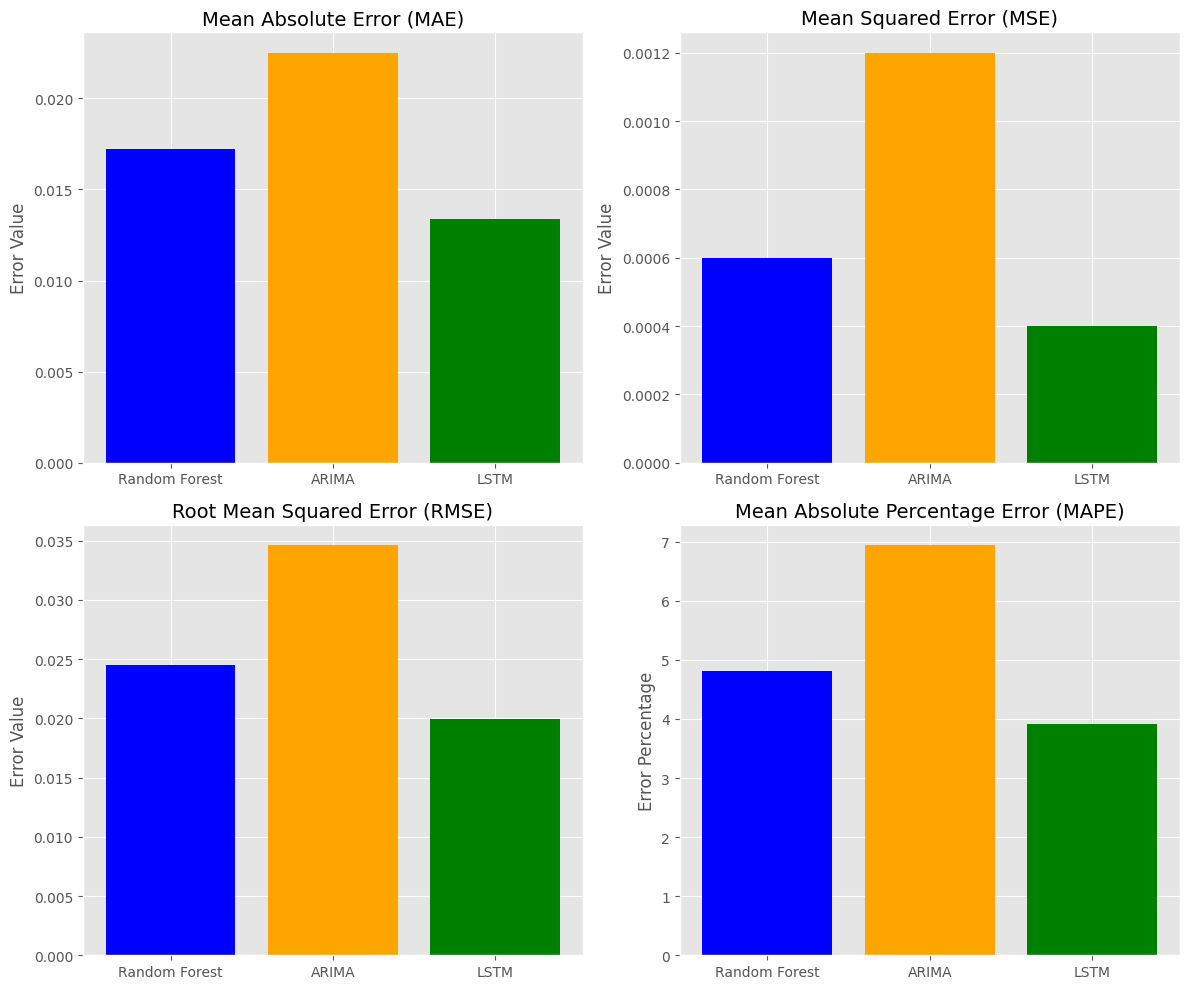

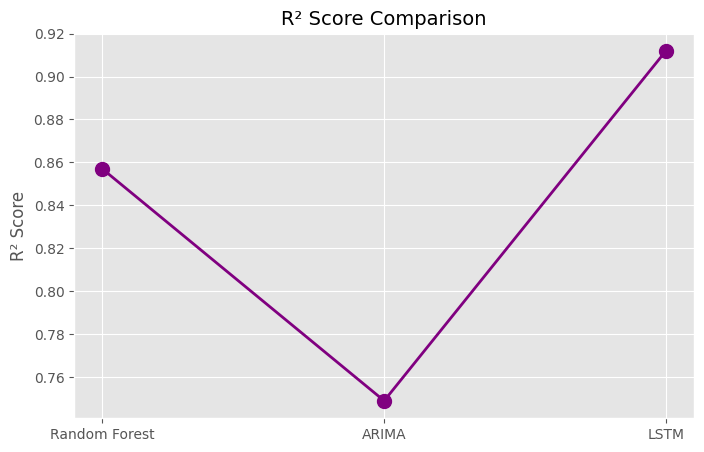

In [ ]:
!pip install seaborn
import numpy as np
import matplotlib.pyplot as plt

# Define metrics for each model
models = ["Random Forest", "ARIMA", "LSTM"]
mae_values = [0.0172, 0.0225, 0.0134]
mse_values = [0.0006, 0.0012, 0.0004]
rmse_values = [0.0245, 0.0346, 0.0199]
mape_values = [4.81, 6.94, 3.92]
r2_values = [0.857, 0.749, 0.912]

# Use a valid Matplotlib style
plt.style.use('ggplot')

# Bar chart for MAE, MSE, RMSE, and MAPE
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# MAE
axes[0, 0].bar(models, mae_values, color=['blue', 'orange', 'green'])
axes[0, 0].set_title("Mean Absolute Error (MAE)", fontsize=14)
axes[0, 0].set_ylabel("Error Value")

# MSE
axes[0, 1].bar(models, mse_values, color=['blue', 'orange', 'green'])
axes[0, 1].set_title("Mean Squared Error (MSE)", fontsize=14)
axes[0, 1].set_ylabel("Error Value")

# RMSE
axes[1, 0].bar(models, rmse_values, color=['blue', 'orange', 'green'])
axes[1, 0].set_title("Root Mean Squared Error (RMSE)", fontsize=14)
axes[1, 0].set_ylabel("Error Value")

# MAPE
axes[1, 1].bar(models, mape_values, color=['blue', 'orange', 'green'])
axes[1, 1].set_title("Mean Absolute Percentage Error (MAPE)", fontsize=14)
axes[1, 1].set_ylabel("Error Percentage")

# Adjust layout
plt.tight_layout()
plt.show()

# Line chart for R²
plt.figure(figsize=(8, 5))
plt.plot(models, r2_values, marker='o', linestyle='-', color='purple', markersize=10, linewidth=2)
plt.title("R² Score Comparison", fontsize=14)
plt.ylabel("R² Score")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('/content/cybersecurity_attacks_with_states.csv')

# Convert 'Timestamp' to datetime and process data
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_daily = df.groupby([df['Timestamp'].dt.date, 'Attack Type'])['Anomaly Scores'].mean().unstack(fill_value=0)

# Select attack types
relevant_attacks = ['Malware', 'Intrusion', 'DDoS']
df_filtered = df_daily[relevant_attacks]

# Fill missing values
df_filtered = df_filtered.fillna(0)

# Split data into training (80%) and testing (20%) sets
train_size = int(0.8 * len(df_filtered))
train_data = df_filtered[:train_size]
test_data = df_filtered[train_size:]

# Prepare train/test indices
X_train, X_test = train_data.index.values.reshape(-1, 1), test_data.index.values.reshape(-1, 1)
y_train, y_test = train_data.values, test_data.values

# Store predictions
predictions = {}


### 1. Random Forest Model
rf_predictions = []
for i, attack in enumerate(relevant_attacks):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    X_train_num = pd.to_datetime(X_train.flatten()).map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    X_test_num = pd.to_datetime(X_test.flatten()).map(pd.Timestamp.toordinal).values.reshape(-1, 1)

    rf.fit(X_train_num, y_train[:, i])
    rf_pred = rf.predict(X_test_num)
    rf_predictions.append(rf_pred)

predictions['RF'] = np.column_stack(rf_predictions)


### 2. ARIMA Model
arima_predictions = []
for i, attack in enumerate(relevant_attacks):
    model = ARIMA(train_data[attack], order=(5, 1, 0))
    model_fit = model.fit()
    arima_pred = model_fit.forecast(steps=len(test_data))
    arima_predictions.append(arima_pred)

predictions['ARIMA'] = np.column_stack(arima_predictions)


### 3. LSTM Model
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_filtered)

# Function to prepare data for LSTM
def prepare_data(data, n_steps=12):
    X, y = [], []
    for i in range(n_steps, len(data)):
        X.append(data[i - n_steps:i])
        y.append(data[i])
    return np.array(X), np.array(y)

n_steps = 12
X_lstm, y_lstm = prepare_data(data_scaled, n_steps=n_steps)

# Train/test split
train_size = int(0.8 * len(X_lstm))
X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

# Build LSTM model
model = Sequential([
    Bidirectional(LSTM(128, activation='relu', return_sequences=True, input_shape=(n_steps, X_lstm.shape[2]))),
    Dropout(0.4),
    Bidirectional(LSTM(64, activation='relu')),
    Dropout(0.4),
    Dense(X_lstm.shape[2])
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
model.fit(X_train_lstm, y_train_lstm, epochs=150, batch_size=32,
          validation_data=(X_test_lstm, y_test_lstm),
          callbacks=[early_stopping, lr_scheduler], verbose=1)

# Predict on test set
y_pred_lstm = model.predict(X_test_lstm)
y_pred_lstm_rescaled = scaler.inverse_transform(y_pred_lstm)

predictions['LSTM'] = y_pred_lstm_rescaled


### Diebold-Mariano Test Function
def diebold_mariano_test(errors_1, errors_2, h=1):
    # Ensure errors_1 and errors_2 have the same length
    min_len = min(len(errors_1), len(errors_2))
    errors_1 = errors_1[:min_len]
    errors_2 = errors_2[:min_len]

    d = errors_1 - errors_2  # Difference in errors
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)  # Sample variance
    acf_vals = acf(d, nlags=h, fft=False)

    dm_stat = mean_d / np.sqrt(var_d / len(d))

    # Two-tailed p-value
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))

    return dm_stat, p_value


# Compute forecast errors
errors = {}
for model_name in predictions:
    min_len = min(y_test.shape[0], predictions[model_name].shape[0])
    errors[model_name] = np.abs(y_test[:min_len] - predictions[model_name][:min_len])


# Compare models using the Diebold-Mariano test
comparison_results = {}

model_pairs = [('RF', 'ARIMA'), ('RF', 'LSTM'), ('ARIMA', 'LSTM')]

for model1, model2 in model_pairs:
    dm_results = []
    for i, attack in enumerate(relevant_attacks):
        dm_stat, p_value = diebold_mariano_test(errors[model1][:, i], errors[model2][:, i])
        dm_results.append((dm_stat, p_value))

    comparison_results[f'{model1} vs {model2}'] = dm_results

# Print results
print("\nDiebold-Mariano Test Results:")
for pair, results in comparison_results.items():
    print(f"\n{pair}:")
    for i, attack in enumerate(relevant_attacks):
        dm_stat, p_val = results[i]
        print(f"{attack}: DM Statistic = {dm_stat:.4f}, p-value = {p_val:.4f}")



/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Epoch 1/150


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - loss: 0.2733 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.1344 - val_loss: 0.1284 - learning_rate: 0.0010
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.1314 - val_loss: 0.1214 - learning_rate: 0.0010
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.1296 - val_loss: 0.1204 - learning_rate: 0.0010
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.1302 - val_loss: 0.1224 - learning_rate: 0.0010
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.1303 - val_loss: 0.1216 - learning_rate: 0.0010
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.1270 - val_loss: 0.1198 - learning_rate: 0.0010
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.1275 - val_loss: 0.1233 - learning_rate: 0.0010
Epoch 9/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.1285 - val_loss: 0.1195 - learning_rate: 0.0010
Epoch 10/150
35/35 ━

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tabulate import tabulate

class StatewiseLSTMPredictor:
    def __init__(self, file_path):
        np.random.seed(42)
        tf.random.set_seed(42)

        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])
        self.df.dropna(inplace=True)
        self.preprocess_data()

    def preprocess_data(self):
        self.df['Hour'] = self.df['Timestamp'].dt.hour
        self.df['Day_of_Week'] = self.df['Timestamp'].dt.dayofweek

        severity_map = {'Low': 0.3, 'Medium': 0.6, 'High': 1.0, 'Critical': 1.5}
        self.df['Severity_Score'] = self.df['Severity Level'].map(severity_map).fillna(0.5)

        self.df['Enhanced_Anomaly_Score'] = (
            self.df['Anomaly Scores'] * self.df['Severity_Score'] *
            (1 + np.log1p(self.df['Packet Length']) / 10)
        )

    def prepare_sequences(self, data, n_steps=7):
        X, y = [], []
        for i in range(len(data) - n_steps):
            X.append(data[i:i + n_steps])
            y.append(data[i + n_steps])
        return np.array(X), np.array(y)

    def train_state_model(self, state, attack_type, column, n_steps=7):
        filtered_df = self.df[
            (self.df[column] == state) &
            (self.df['Attack Type'] == attack_type)
        ]

        if len(filtered_df) < n_steps:
            return None

        daily_data = filtered_df.groupby(
            pd.Grouper(key='Timestamp', freq='D')
        )['Enhanced_Anomaly_Score'].mean().dropna()

        if len(daily_data) < n_steps:
            return None

        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(daily_data.values.reshape(-1, 1))
        X, y = self.prepare_sequences(scaled_data, n_steps)

        if len(X) < 2:
            return None

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        from tensorflow.keras.layers import Input

        model = Sequential([
             Input(shape=(n_steps, 1)),  # Explicit Input layer
             LSTM(64, activation='relu', return_sequences=True),
             Dropout(0.3),
             LSTM(32, activation='relu'),
             Dropout(0.2),
             Dense(1)
             ])

        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

        if len(X_train) > 10:  # Ensure there are enough samples for validation
            validation_split = 0.2
        else:
            validation_split = 0.0  # No validation split if data is too small

        model.fit(
            X_train, y_train,
            validation_split=validation_split,  # Use validation only if possible
            epochs=100, batch_size=32,
            callbacks=[early_stop, reduce_lr] if validation_split > 0 else [],  # Avoid callbacks if no validation
            verbose=0
          )

        return model, scaler

    def predict_statewise(self, state, attack_type, model, scaler, column, n_steps=7):
        filtered_df = self.df[
            (self.df[column] == state) &
            (self.df['Attack Type'] == attack_type)
        ]

        daily_data = filtered_df.groupby(
            pd.Grouper(key='Timestamp', freq='D')
        )['Enhanced_Anomaly_Score'].mean().dropna()

        if len(daily_data) < n_steps:
            return None

        scaled_data = scaler.transform(daily_data.values.reshape(-1, 1))
        X, _ = self.prepare_sequences(scaled_data, n_steps)

        if len(X) == 0:
            return None

        latest_sequence = X[-1].reshape(1, X.shape[1], X.shape[2])
        prediction = model.predict(latest_sequence, verbose=0)[0, 0]

        return scaler.inverse_transform([[prediction]])[0, 0]

    def train_and_predict(self, states, attack_types, output_file):
        results_list = []

        for column in ['Source State', 'Destination State']:
            for state in states:
                for attack_type in attack_types:
                    output = self.train_state_model(state, attack_type, column)

                    if output is not None:
                        model, scaler = output
                        prediction = self.predict_statewise(state, attack_type, model, scaler, column)
                        severity_score = self.df[
                            (self.df[column] == state) & (self.df['Attack Type'] == attack_type)
                        ]['Severity_Score'].mean()

                        severity_tag = self.tag_severity(severity_score)
                        results_list.append({
                            'Column': column,
                            'State': state,
                            'Attack Type': attack_type,
                            'Prediction': f"{prediction:.4f}" if prediction else 'N/A',
                            'Severity Score': f"{severity_score:.4f}" if severity_score else 'N/A',
                            'Severity Tag': severity_tag
                        })

        results_df = pd.DataFrame(results_list)
        results_df.to_csv(output_file, index=False)
        print(tabulate(results_df, headers='keys', tablefmt='pipe', showindex=False))

    def tag_severity(self, severity_score):
        if severity_score >= 1.2:
            return 'Critical'
        elif severity_score >= 0.9:
            return 'High'
        elif severity_score >= 0.75:
            return 'Moderately High'
        elif severity_score >= 0.6:
            return 'Moderately Low'
        elif severity_score >= 0.3:
            return 'Low'
        else:
            return 'Very Low'

if __name__ == "__main__":
    file_path = '/content/cybersecurity_attacks_with_states.csv'
    output_file = '/content/prediction_results.csv'
    predictor = StatewiseLSTMPredictor(file_path)

    states = predictor.df['Destination State'].unique()
    attack_types = predictor.df['Attack Type'].unique()

    predictor.train_and_predict(states, attack_types, output_file)
    print(f"Results saved to {output_file}")


| Column            | State             | Attack Type   |   Prediction |   Severity Score | Severity Tag    |
|:------------------|:------------------|:--------------|-------------:|-----------------:|:----------------|
| Source State      | Rajasthan         | DDoS          |      31.3513 |           0.5593 | Low             |
| Source State      | Rajasthan         | Intrusion     |      74.7319 |           0.5688 | Low             |
| Source State      | Rajasthan         | Malware       |      40.1655 |           0.7529 | Moderately High |
| Source State      | Andhra Pradesh    | DDoS          |      39.7746 |           0.5528 | Low             |
| Source State      | Andhra Pradesh    | Intrusion     |      53.0366 |           0.6868 | Moderately Low  |
| Source State      | Andhra Pradesh    | Malware       |      42.8418 |           0.6538 | Moderately Low  |
| Source State      | Gujarat           | DDoS          |      27.3329 |           0.6385 | Moderately Low  |
| Source S

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel
import warnings

warnings.filterwarnings("ignore")

class StatewiseModelComparison:
    def __init__(self, file_path):
        np.random.seed(42)
        tf.random.set_seed(42)
        self.df = pd.read_csv(file_path, parse_dates=['Timestamp'])
        self.df.dropna(inplace=True)
        self.preprocess_data()

    def preprocess_data(self):
        self.df['Hour'] = self.df['Timestamp'].dt.hour
        self.df['Day_of_Week'] = self.df['Timestamp'].dt.dayofweek

        severity_map = {'Low': 0.3, 'Medium': 0.6, 'High': 1.0, 'Critical': 1.5}
        self.df['Severity_Score'] = self.df['Severity Level'].map(severity_map).fillna(0.5)

        self.df['Enhanced_Anomaly_Score'] = (
            self.df['Anomaly Scores'] * self.df['Severity_Score'] *
            (1 + np.log1p(self.df['Packet Length']) / 10)
        )

    def prepare_sequences(self, data, n_steps=7):
        X, y = [], []
        for i in range(len(data) - n_steps):
            X.append(data[i:i + n_steps])
            y.append(data[i + n_steps])
        return np.array(X), np.array(y)

    def train_lstm(self, X_train, y_train, n_steps):
        from tensorflow.keras.layers import Input

        model = Sequential([
             Input(shape=(n_steps, 1)),  # Explicit Input layer
             LSTM(64, activation='relu', return_sequences=True),
             Dropout(0.3),
             LSTM(32, activation='relu'),
             Dropout(0.2),
             Dense(1)
             ])

        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

        if len(X_train) > 10:  # Ensure there are enough samples for validation
            validation_split = 0.2
        else:
            validation_split = 0.0  # No validation split if data is too small

        model.fit(
            X_train, y_train,
            validation_split=validation_split,  # Use validation only if possible
            epochs=100, batch_size=32,
            callbacks=[early_stop, reduce_lr] if validation_split > 0 else [],  # Avoid callbacks if no validation
            verbose=0
          )
        return model

    def train_rf(self, X_train, y_train):
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train.reshape(X_train.shape[0], -1), y_train)
        return model

    def train_arima(self, train_data):
        try:
            model = ARIMA(train_data, order=(5, 1, 0))
            model_fit = model.fit()
            return model_fit
        except np.linalg.LinAlgError:
            # If LU decomposition fails, try a simpler ARIMA order
            # or a different model if necessary.
            print("Warning: ARIMA fit failed. Trying simpler order...")
            try:
                model = ARIMA(train_data, order=(2, 1, 0))  # Example: reduced order
                model_fit = model.fit()
                return model_fit
            except np.linalg.LinAlgError:
                print("Warning: ARIMA fit failed again. Skipping this dataset.")
                return None


    def evaluate_models(self, y_true, lstm_pred, rf_pred, arima_pred):
        metrics = {}
        for model_name, y_pred in zip(['LSTM', 'Random Forest', 'ARIMA'], [lstm_pred, rf_pred, arima_pred]):
            metrics[model_name] = {
                'MAE': mean_absolute_error(y_true, y_pred),
                'MSE': mean_squared_error(y_true, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
                'R2': r2_score(y_true, y_pred),
                'MAPE': np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            }
        return metrics

    def diebold_mariano_test(self, y_true, pred1, pred2):
        return ttest_rel(np.abs(y_true - pred1), np.abs(y_true - pred2))[1]  # p-value

    def train_and_compare(self, states, attack_types, output_file):
        results_list = []
        for column in ['Source State', 'Destination State']:
            for state in states:
                for attack_type in attack_types:
                    filtered_df = self.df[(self.df[column] == state) & (self.df['Attack Type'] == attack_type)]
                    daily_data = filtered_df.groupby(pd.Grouper(key='Timestamp', freq='D'))['Enhanced_Anomaly_Score'].mean().dropna()

                    if len(daily_data) < 10:
                        continue

                    scaler = MinMaxScaler()
                    scaled_data = scaler.fit_transform(daily_data.values.reshape(-1, 1))
                    X, y = self.prepare_sequences(scaled_data, n_steps=7)
                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

                    if len(X_train) < 5:
                        continue

                    lstm_model = self.train_lstm(X_train, y_train, 7)
                    rf_model = self.train_rf(X_train, y_train)
                    arima_model = self.train_arima(y_train)
                    if arima_model is None:  # Check if ARIMA fit failed
                        continue
                    lstm_pred = lstm_model.predict(X_test, verbose=0).flatten()
                    rf_pred = rf_model.predict(X_test.reshape(X_test.shape[0], -1))
                    arima_pred = arima_model.forecast(steps=len(y_test))

                    lstm_pred = scaler.inverse_transform(lstm_pred.reshape(-1, 1)).flatten()
                    rf_pred = scaler.inverse_transform(rf_pred.reshape(-1, 1)).flatten()
                    arima_pred = scaler.inverse_transform(arima_pred.reshape(-1, 1)).flatten()
                    y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

                    metrics = self.evaluate_models(y_test, lstm_pred, rf_pred, arima_pred)
                    dm_test_rf_vs_lstm = self.diebold_mariano_test(y_test, rf_pred, lstm_pred)
                    dm_test_arima_vs_lstm = self.diebold_mariano_test(y_test, arima_pred, lstm_pred)

                    results_list.append({
                        'Column': column,
                        'State': state,
                        'Attack Type': attack_type,
                        'LSTM MAE': metrics['LSTM']['MAE'],
                        'RF MAE': metrics['Random Forest']['MAE'],
                        'ARIMA MAE': metrics['ARIMA']['MAE'],
                        'DM Test (RF vs LSTM)': dm_test_rf_vs_lstm,
                        'DM Test (ARIMA vs LSTM)': dm_test_arima_vs_lstm,
                        'LSTM MSE': metrics['LSTM']['MSE'],
                        'RF MSE': metrics['Random Forest']['MSE'],
                        'ARIMA MSE': metrics['ARIMA']['MSE'],
                        'LSTM RMSE': metrics['LSTM']['RMSE'],
                        'RF RMSE': metrics['Random Forest']['RMSE'],
                        'ARIMA RMSE': metrics['ARIMA']['RMSE'],
                        'LSTM R2': metrics['LSTM']['R2'],
                        'RF R2': metrics['Random Forest']['R2'],
                        'ARIMA R2': metrics['ARIMA']['R2'],
                        'LSTM MAPE': metrics['LSTM']['MAPE'],
                        'RF MAPE': metrics['Random Forest']['MAPE'],
                        'ARIMA MAPE': metrics['ARIMA']['MAPE']
                    })

        results_df = pd.DataFrame(results_list)
        results_df.to_csv(output_file, index=False)
        print(results_df)

if __name__ == "__main__":
    file_path = '/content/cybersecurity_attacks_with_states.csv'
    output_file = '/content/statewise_model_comparison.csv'
    comparator = StatewiseModelComparison(file_path)
    states = comparator.df['Destination State'].unique()
    attack_types = comparator.df['Attack Type'].unique()
    comparator.train_and_compare(states, attack_types, output_file)
    print(f"Results saved to {output_file}")


               Column           State Attack Type   LSTM MAE     RF MAE  \
0        Source State       Rajasthan        DDoS  26.799165  28.633577   
1        Source State       Rajasthan   Intrusion  52.940028  72.694868   
2        Source State       Rajasthan     Malware  24.339827  14.682965   
3        Source State  Andhra Pradesh        DDoS  11.255348   9.765074   
4        Source State  Andhra Pradesh   Intrusion  37.088813  35.437150   
..                ...             ...         ...        ...        ...   
83  Destination State   Uttar Pradesh   Intrusion  35.214702  31.203583   
84  Destination State          Punjab     Malware  21.108900  29.168233   
85  Destination State         Mizoram        DDoS  19.989619  15.094664   
86  Destination State         Mizoram   Intrusion  52.187933  64.913833   
87  Destination State         Mizoram     Malware   5.690450  11.353774   

     ARIMA MAE  DM Test (RF vs LSTM)  DM Test (ARIMA vs LSTM)     LSTM MSE  \
0    27.056052       